# Classificação — Fashion-MNIST

Preparação do primeiro experimento com MLP e SGD puro. 

Esta configuração é inicial: o baseline definitivo será escolhido pelo desempenho na validação. O conjunto de teste fica reservado à avaliação final.

In [2]:
from pathlib import Path
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset, random_split
from torchvision import datasets
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from IPython.display import Image, display
import copy
import json
import math
from datetime import datetime
from time import perf_counter
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

## 1. Carregamento e distribuição de classes

A função separa treino e validação, verifica as proporções de classes e salva o gráfico. O conjunto de teste já vem separado no Fashion-MNIST.

In [11]:
BASE_DIR = Path.cwd().resolve()
if BASE_DIR.name == "notebooks":
    BASE_DIR = BASE_DIR.parent
if not (BASE_DIR / "README.md").is_file():
    raise RuntimeError("Execute pela raiz do projeto ou pela pasta notebooks.")
DATA_DIR = BASE_DIR / "data"
FIGURES_DIR = BASE_DIR / "results" / "figures"
print(f"Projeto: {BASE_DIR}")

Projeto: C:\Users\davis\Documents\vscode\redesNeuraisUC\mlp_rn


In [12]:
def preparar_tensores(dataset):
    #Transforma o dataset em tensores PyTorch, normalizando as imagens
    imagens = dataset.data.to(dtype=torch.float32).unsqueeze(1)
    imagens.div_(255.0).sub_(0.2860).div_(0.3530)
    rotulos = dataset.targets.to(dtype=torch.long)
    return TensorDataset(imagens, rotulos)

Compara cada classe entre treino, validação e teste, com tolerância em 3%.

In [13]:
def check_class_distribution(targets_by_split, class_names, tolerance=0.03):
    if not 0 <= tolerance <= 1:
        raise ValueError("A tolerância deve estar entre 0 e 1.")

    proportions = {}
    for name, targets in targets_by_split.items():
        targets = torch.as_tensor(targets, dtype=torch.long)
        if targets.numel() == 0:
            raise ValueError(f"O conjunto {name} está vazio.")
        counts = torch.bincount(targets, minlength=len(class_names))
        proportions[name] = counts.to(torch.float64) / targets.numel()

    values = torch.stack(list(proportions.values()))
    differences = values.max(dim=0).values - values.min(dim=0).values
    print("\nDistribuição de classes (proporção em cada conjunto):")
    print(f"{'Classe':<24}" + "".join(f"{name:>12}" for name in proportions) + "  Dif. (p.p.)")
    violations = []
    for index, class_name in enumerate(class_names):
        print(
            f"{class_name:<24}"
            + "".join(f"{p[index].item():>11.2%} " for p in proportions.values())
            + f"{differences[index].item() * 100:>10.2f}"
        )
        if differences[index].item() > tolerance + 1e-12:
            violations.append(class_name)

    if violations:
        raise ValueError(
            f"Diferença acima de {tolerance * 100:g} pontos percentuais "
            f"nas classes: {', '.join(violations)}."
        )
    print(f"Distribuições dentro da tolerância de {tolerance * 100:g} p.p.\n")
    return proportions

Gráfico para o relatório.

In [14]:
def plot_class_distribution(proportions, class_names, output_dir=FIGURES_DIR):

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    colors = ("#0072B2", "#E69F00", "#009E73")
    with plt.rc_context({"font.size": 11, "axes.spines.top": False,
                         "axes.spines.right": False, "pdf.fonttype": 42}):
        fig, ax = plt.subplots(figsize=(13, 6), layout="constrained")
        try:
            width = 0.8 / len(proportions)
            for i, (name, values) in enumerate(proportions.items()):
                positions = [x + (i - (len(proportions) - 1) / 2) * width
                             for x in range(len(class_names))]
                ax.bar(positions, values.detach().cpu().tolist(), width=width,
                       label=name, color=colors[i % len(colors)], zorder=3)

            ax.axhline(1 / len(class_names), color="#555555", linestyle="--",
                       linewidth=1, label="Distribuição uniforme", zorder=2)
            ax.set_title("Distribuição de classes — Fashion-MNIST", loc="left",
                         fontsize=17, fontweight="bold", pad=18)
            ax.set_ylabel("Proporção de amostras no conjunto")
            ax.set_xticks(range(len(class_names)), class_names,
                          rotation=30, ha="right")
            ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
            ax.set_ylim(0, max(p.max().item() for p in proportions.values()) * 1.25)
            ax.grid(axis="y", alpha=0.2, zorder=0)
            ax.legend(frameon=False, ncol=4, loc="upper center")
            paths = [output_dir / f"fashion_mnist_class_distribution.{ext}"
                     for ext in ("png", "pdf")]
            for path in paths:
                fig.savefig(path, dpi=300, bbox_inches="tight", facecolor="white")
                print(f"Gráfico salvo em: {path}")
            return paths
        finally:
            plt.close(fig)

Separa treino e validação e organiza os lotes. O teste permanece separado.

In [15]:
def load_fashion_mnist(train_batch_size=64, test_batch_size=64, seed=42, class_distribution_tolerance=0.03, save_distribution_plot=True):

    dataset_root = DATA_DIR / "fashion_mnist"
    dataset_root.mkdir(parents=True, exist_ok=True)
    torch.manual_seed(seed)

    train_raw = datasets.FashionMNIST(root=str(dataset_root), train=True, download=True)
    test_raw = datasets.FashionMNIST(root=str(dataset_root), train=False, download=True)
    class_names = list(train_raw.classes)
    train_full = preparar_tensores(train_raw)
    test_full = preparar_tensores(test_raw)

    #Separa o conjunto de treino em treino e validação, mantendo a distribuição de classes (80/20)
    train_size = int(0.8 * len(train_full))
    val_size = len(train_full) - train_size
    generator = torch.Generator().manual_seed(seed)
    train_ds, val_ds = random_split(train_full, [train_size, val_size], generator=generator)

    proportions = check_class_distribution(
        {
            "Treino": train_full.tensors[1][train_ds.indices],
            "Validação": train_full.tensors[1][val_ds.indices],
            "Teste": test_full.tensors[1],
        },
        class_names,
        tolerance=class_distribution_tolerance,
    )
    if save_distribution_plot:
        plot_class_distribution(proportions, class_names)

    train_loader = DataLoader(train_ds, batch_size=train_batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=test_batch_size, shuffle=False)
    test_loader = DataLoader(test_full, batch_size=test_batch_size, shuffle=False)
    return train_loader, val_loader, test_loader, class_names


Distribuição de classes (proporção em cada conjunto):
Classe                        Treino   Validação       Teste  Dif. (p.p.)
T-shirt/top                   9.86%      10.57%      10.00%       0.71
Trouser                       9.90%      10.40%      10.00%       0.50
Pullover                     10.05%       9.79%      10.00%       0.26
Dress                        10.11%       9.57%      10.00%       0.54
Coat                         10.01%       9.94%      10.00%       0.07
Sandal                        9.99%      10.03%      10.00%       0.03
Shirt                         9.98%      10.10%      10.00%       0.13
Sneaker                      10.14%       9.45%      10.00%       0.69
Bag                          10.01%       9.96%      10.00%       0.05
Ankle boot                    9.95%      10.20%      10.00%       0.25
Distribuições dentro da tolerância de 3 p.p.

Gráfico salvo em: C:\Users\davis\Documents\vscode\redesNeuraisUC\mlp_rn\results\figures\fashion_mnist_class_distrib

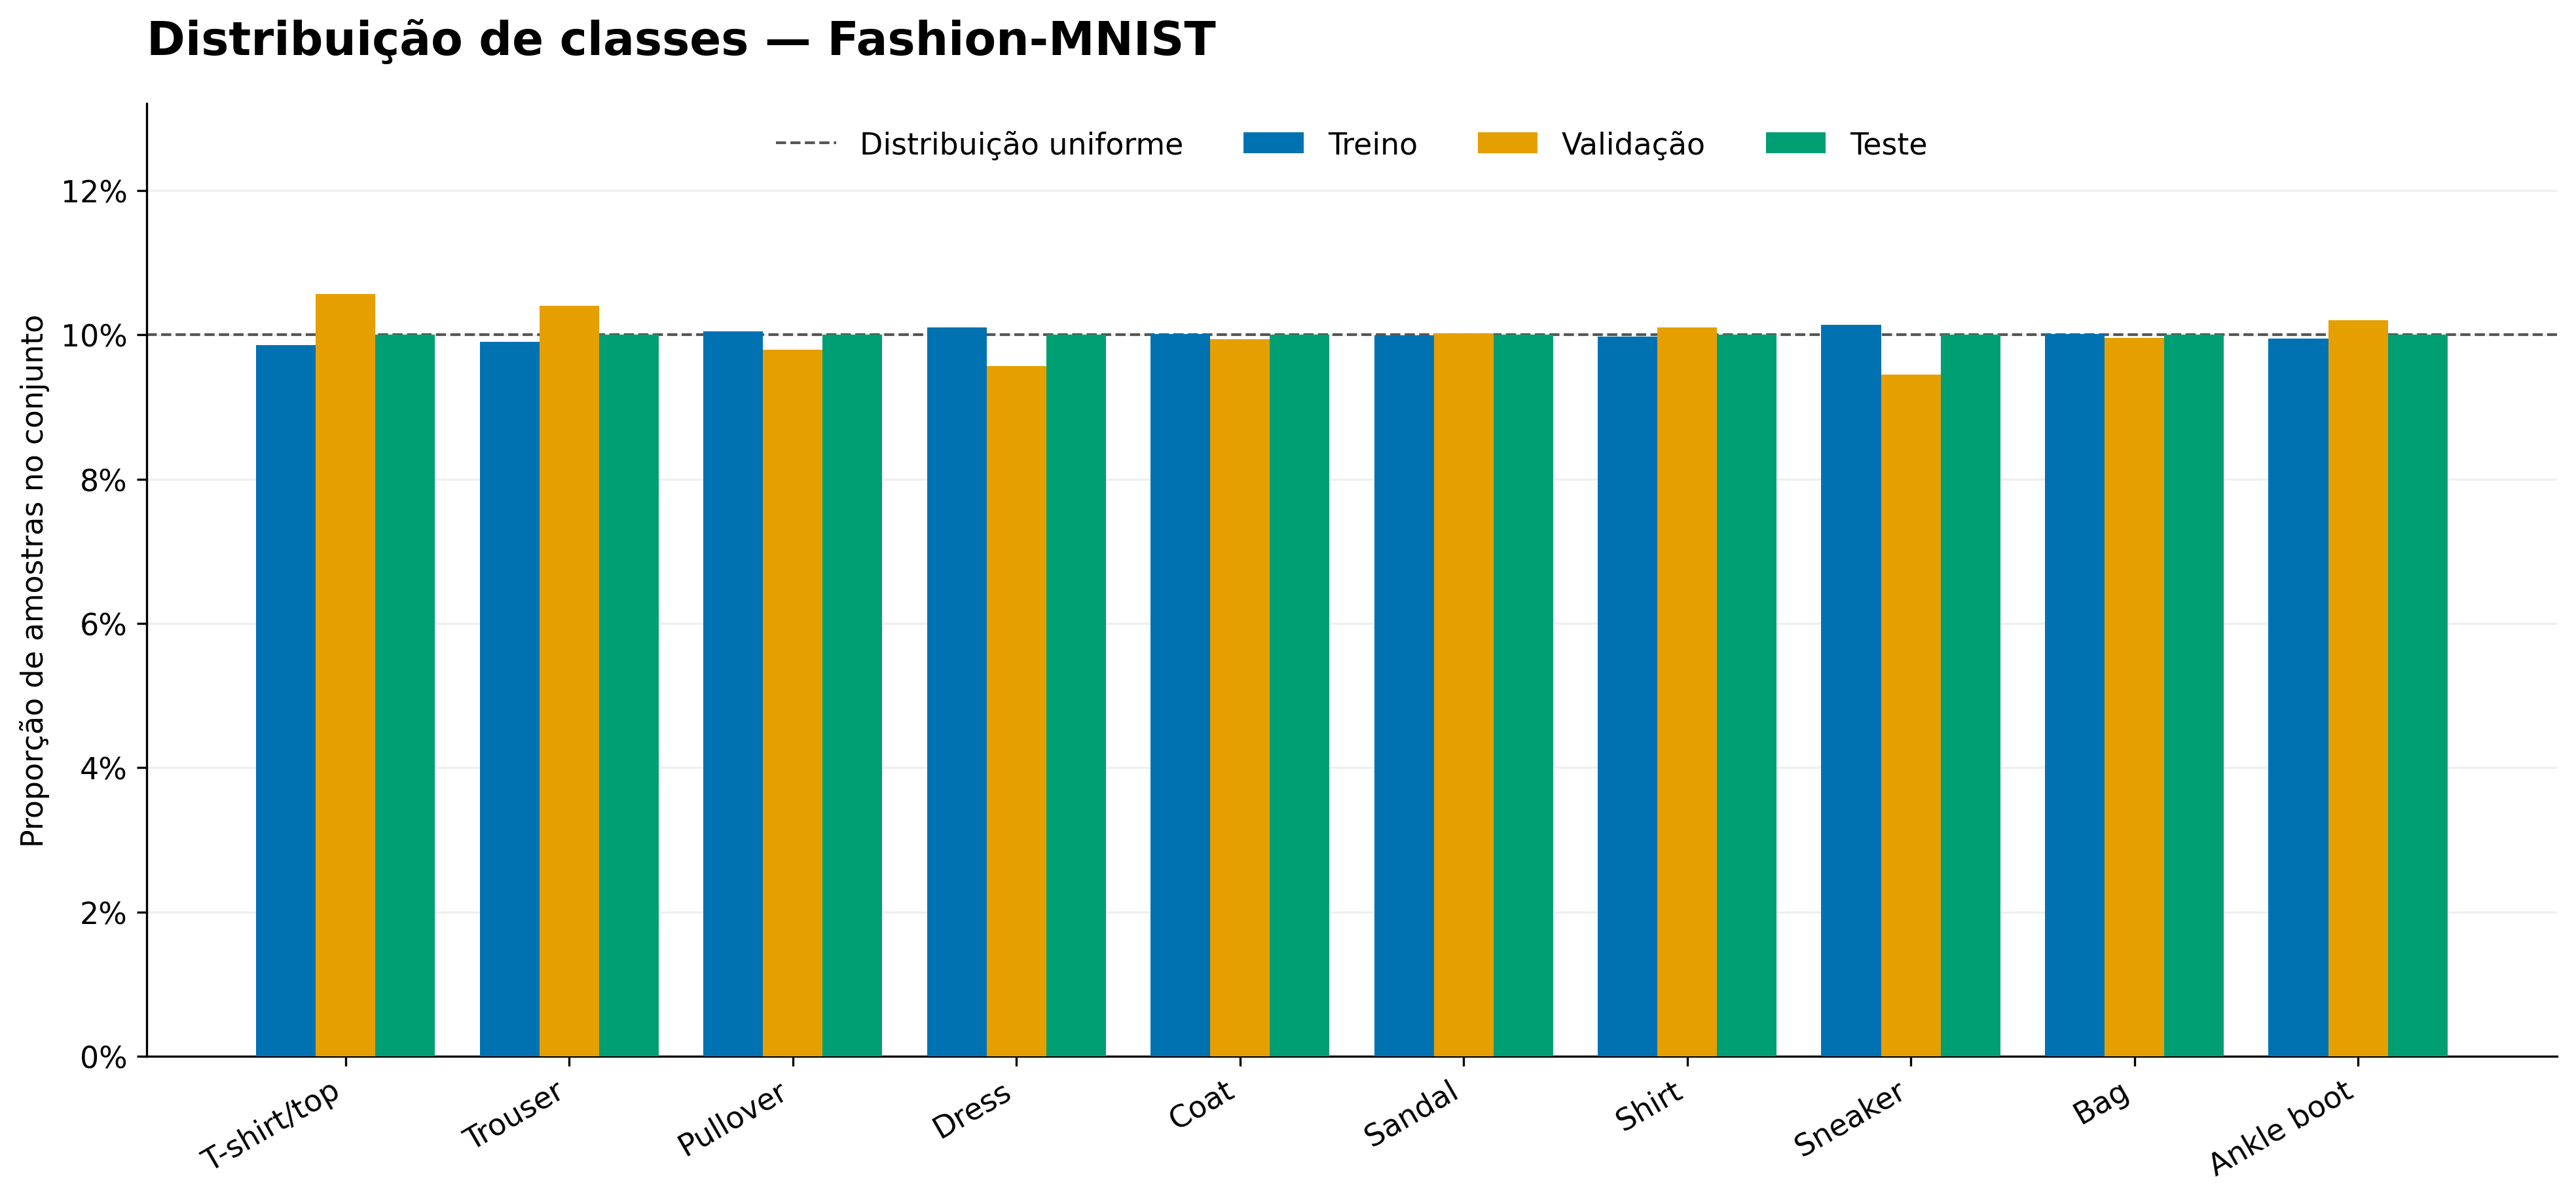

In [16]:
SEED = 42
BATCH_SIZE = 64
CLASS_DISTRIBUTION_TOLERANCE = 0.03 

train_loader, val_loader, test_loader, class_names = load_fashion_mnist(
    train_batch_size=BATCH_SIZE,
    test_batch_size=BATCH_SIZE,
    seed=SEED,
    class_distribution_tolerance=CLASS_DISTRIBUTION_TOLERANCE,
)

print(f"Treino: {len(train_loader.dataset):,} imagens")
print(f"Validação: {len(val_loader.dataset):,} imagens")
print(f"Teste: {len(test_loader.dataset):,} imagens")
display(Image(filename=str(FIGURES_DIR / "fashion_mnist_class_distribution.png")))

Mostramos uma imagem de cada uma das 10 classes, na ordem dos rótulos.

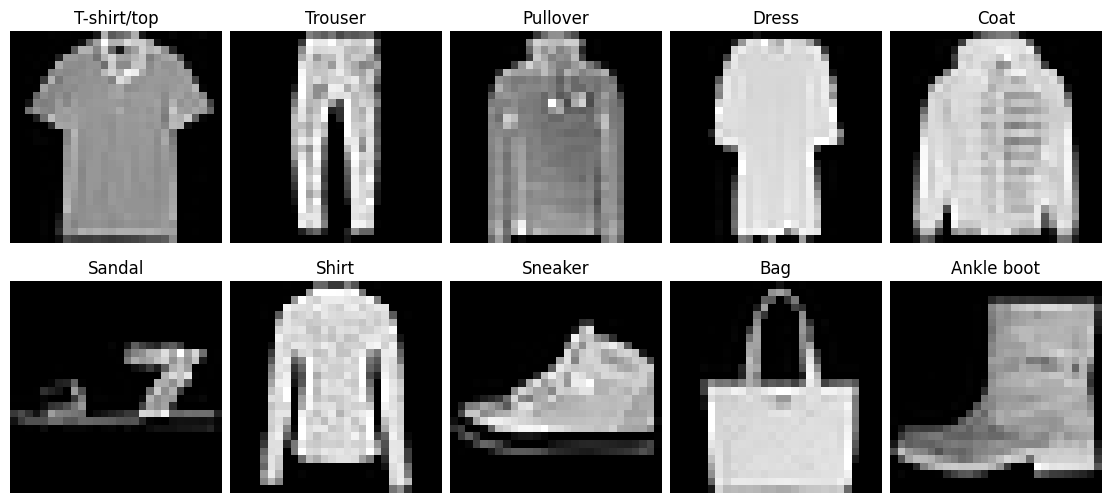

In [ ]:
examples = {}
for image, label in train_loader.dataset:
    label = int(label)
    if label not in examples:
        examples[label] = image
    if len(examples) == len(class_names):
        break

if len(examples) != len(class_names):
    raise ValueError("O conjunto de treino não contém exemplos de todas as classes.")

fig, axes = plt.subplots(2, 5, figsize=(11, 5), layout="constrained")
for label, ax in enumerate(axes.flat):
    image = examples[label]
    image_for_display = (image * 0.3530 + 0.2860).clamp(0, 1)
    ax.imshow(image_for_display.squeeze(0), cmap="gray", vmin=0, vmax=1)
    ax.set_title(class_names[label])
    ax.axis("off")
plt.show()
plt.close(fig)

## 2. Geração do Baseline (Vanilla)

- Usar SGD e deve ser uma MLP básica.

- Fazer uma configuração inicial.

- Testar treinamento padrão, batch e mini-batch para a configuração inicial.

- Vamos testar diversas abordagens (combinações de hiperparâmetros) e selecionar o de melhor desempenho.

- Selecionar melhor modelo encontrado.

### Funções de treinamento e avaliação:
- Criar modelo
- Avaliar
- Treinar

In [18]:
#Criando modelo baseline com arquitetura e hiperparâmetros definidos no dicionário config_inicial

def criar_modelo_baseline(config, num_classes=10):
    ativacoes = {"relu": nn.ReLU, "tanh": nn.Tanh, "sigmoid": nn.Sigmoid}
    if config["optimizer"].lower() != "sgd":
        raise ValueError("O baseline deve usar SGD puro.")
    if config["ativacao"] not in ativacoes:
        raise ValueError("Ativação deve ser relu, tanh ou sigmoid.")
    if not config["arquitetura"] or any(
        type(n) is not int or n <= 0 for n in config["arquitetura"]
    ):
        raise ValueError("Arquitetura deve conter números inteiros positivos.")
    for nome in ("batch_size", "epochs"):
        if type(config[nome]) is not int or config[nome] <= 0:
            raise ValueError(f"{nome} deve ser um inteiro positivo.")
    if not math.isfinite(config["learning_rate"]) or config["learning_rate"] <= 0:
        raise ValueError("learning_rate deve ser positivo e finito.")

    camadas = [nn.Flatten()]
    #28 * 28 = 784 entradas, pois cada imagem do Fashion-MNIST tem 28x28 pixels.
    entradas = 28 * 28
    for neuronios in config["arquitetura"]:
        camadas.extend([nn.Linear(entradas, neuronios), ativacoes[config["ativacao"]]()])
        entradas = neuronios
    camadas.append(nn.Linear(entradas, num_classes)) 
    return nn.Sequential(*camadas)

In [19]:
#Avalia a perda média por imagem e a acurácia do modelo em um conjunto de dados.
def avaliar_modelo(modelo, loader, criterio, device, nomes_classes=None):
    if len(loader.dataset) == 0:
        raise ValueError("O conjunto de avaliação está vazio.")
    estava_treinando = modelo.training
    modelo.eval()
    perda_total = 0.0
    rotulos, previsoes = [], []
    try:
        with torch.no_grad():
            for imagens, alvos in loader:
                imagens, alvos = imagens.to(device), alvos.to(device)
                saidas = modelo(imagens)
                perda_total += criterio(saidas, alvos).item() * alvos.size(0)
                rotulos.extend(alvos.cpu().tolist())
                previsoes.extend(saidas.argmax(dim=1).cpu().tolist())
    finally:
        modelo.train(estava_treinando)

    metricas = {
        "loss": perda_total / len(rotulos),
        "accuracy": sum(a == b for a, b in zip(rotulos, previsoes)) / len(rotulos),
    }
    if nomes_classes is not None:
        labels = list(range(len(nomes_classes)))
        metricas["relatorio"] = classification_report(
            rotulos, 
            previsoes, 
            labels=labels, 
            target_names=nomes_classes,
            output_dict=True, 
            zero_division=0,
        )
        metricas["matriz_confusao"] = confusion_matrix(
            rotulos, previsoes, labels=labels
        ).tolist()
    return metricas

In [20]:
#Função para treinar o modelo.
def treinar_modelo(config, treino_ds, validacao_ds, nomes_classes, seed=42, device=None, output_dir=None, verbose=True):

    #Cria o modelo, de acordo com a configuração.
    config = copy.deepcopy(config)
    if len(treino_ds) == 0 or len(validacao_ds) == 0:
        raise ValueError("Treino e validação precisam conter imagens.")
    #Se der, usa GPU
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"
    device = torch.device(device)
    torch.manual_seed(seed)
    modelo = criar_modelo_baseline(config, num_classes=len(nomes_classes)).to(device)
    criterio = nn.CrossEntropyLoss()
    #Para o baseline, usamos SGD puro.
    otimizador = torch.optim.SGD(
        modelo.parameters(), lr=config["learning_rate"], momentum=0.0, weight_decay=0.0
    )
    #Carrega os dados de treino e validação.
    loader_treino = DataLoader(
        treino_ds, batch_size=config["batch_size"], shuffle=True, generator=torch.Generator().manual_seed(seed)
    )
    loader_validacao = DataLoader(
        validacao_ds, batch_size=config["batch_size"], shuffle=False
    )
    #Cria diretório de saída para salvar resultados.
    if output_dir is None:
        output_dir = BASE_DIR / "results" / "classification" / datetime.now().strftime("%Y%m%d_%H%M%S_%f")
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    historico = []
    melhor_acuracia, melhor_perda = -1.0, float("inf")
    melhor_epoca, melhores_pesos = None, None
    inicio = perf_counter()
    if verbose:
        print(f"Dispositivo: {device} | Configuração: {config}", flush=True)

    #Treina o modelo por um número definido de épocas, salvando o melhor modelo com base na acurácia nos dados de validação.
    for epoca in range(1, config["epochs"] + 1):
        modelo.train()
        perda_total, acertos, total = 0.0, 0, 0
        for imagens, alvos in loader_treino:
            imagens, alvos = imagens.to(device), alvos.to(device)
            otimizador.zero_grad()
            saidas = modelo(imagens)
            perda = criterio(saidas, alvos)
            if not torch.isfinite(perda).item():
                raise ValueError("A perda deixou de ser finita; revise o learning rate.")
            perda.backward()
            otimizador.step()
            total += alvos.size(0)
            perda_total += perda.item() * alvos.size(0)
            acertos += (saidas.argmax(dim=1) == alvos).sum().item()

        validacao = avaliar_modelo(modelo, loader_validacao, criterio, device)
        if not math.isfinite(validacao["loss"]):
            raise ValueError("A perda de validação deixou de ser finita.")
        historico.append({
            "epoch": epoca, "train_loss": perda_total / total,
            "train_accuracy": acertos / total,
            "val_loss": validacao["loss"], "val_accuracy": validacao["accuracy"],
        })
        if (validacao["accuracy"] > melhor_acuracia or (validacao["accuracy"] == melhor_acuracia and validacao["loss"] < melhor_perda)):
            melhor_acuracia, melhor_perda = validacao["accuracy"], validacao["loss"]
            melhor_epoca = epoca
            melhores_pesos = {nome: valor.detach().cpu().clone() for nome, valor in modelo.state_dict().items()}
            torch.save({"model_state_dict": melhores_pesos, 
                        "config": config,
                        "seed": seed, 
                        "class_names": list(nomes_classes),
                        "epoch": epoca, 
                        "val_accuracy": melhor_acuracia,
                        "val_loss": melhor_perda}, 
                        output_dir / "melhor_modelo.pt")
        pd.DataFrame(historico).to_csv(output_dir / "historico.csv", index=False)
        if verbose:
            print(f"Época {epoca:02d}/{config['epochs']} | "
                  f"treino: perda={perda_total / total:.4f}, acurácia={acertos / total:.2%} | "
                  f"validação: perda={validacao['loss']:.4f}, acurácia={validacao['accuracy']:.2%}",
                  flush=True)

    modelo.load_state_dict(melhores_pesos)
    modelo.eval()
    avaliacao = avaliar_modelo(modelo, loader_validacao, criterio, device, nomes_classes)
    resumo = {
        "config": config, 
        "seed": seed, 
        "device": str(device),
        "train_size": len(treino_ds), 
        "val_size": len(validacao_ds),
        "melhor_epoca": melhor_epoca, 
        "duracao_segundos": perf_counter() - inicio,
        "validacao": avaliacao,
    }
    (output_dir / "resultado.json").write_text(
        json.dumps(resumo, indent=2, ensure_ascii=False), encoding="utf-8"
    )
    if verbose:
        print(f"Melhor época: {melhor_epoca} | Validação: {avaliacao['accuracy']:.2%}")
    if verbose:
        print(f"Resultados salvos em: {output_dir}")
    return {"modelo": modelo, "historico": pd.DataFrame(historico), "resumo": resumo, "output_dir": output_dir}

In [21]:
#Plota os resultados do treinamento, incluindo curvas de perda e acurácia, e a matriz de confusão da melhor época.

def plotar_resultados(resultado, nomes_classes):
    historico = resultado["historico"]
    output_dir = resultado["output_dir"]
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")
    for ax, metrica, titulo in zip(axes, ("loss", "accuracy"), ("Perda", "Acurácia")):
        ax.plot(historico["epoch"], historico[f"train_{metrica}"], label="Treino", color="#0072B2")
        ax.plot(historico["epoch"], historico[f"val_{metrica}"], label="Validação", color="#E69F00")
        ax.axvline(resultado["resumo"]["melhor_epoca"], color="gray", linestyle="--", label="Melhor época")
        ax.set(xlabel="Época", ylabel=titulo, title=titulo)
        if metrica == "accuracy":
            ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
        ax.grid(alpha=0.2)
        ax.legend()
    fig.suptitle("MLP baseline — evolução do treinamento")
    for ext in ("png", "pdf"):
        fig.savefig(output_dir / f"curvas.{ext}", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(10, 8), layout="constrained")
    matriz = resultado["resumo"]["validacao"]["matriz_confusao"]
    ConfusionMatrixDisplay(
        confusion_matrix=torch.tensor(matriz).numpy(), display_labels=nomes_classes
    ).plot(ax=ax, cmap="Blues", colorbar=False, xticks_rotation=45)
    ax.set(title="Matriz de confusão — validação da melhor época",
           xlabel="Classe prevista", ylabel="Classe verdadeira")
    for ext in ("png", "pdf"):
        fig.savefig(output_dir / f"matriz_confusao_validacao.{ext}", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

### Experimento com a configuração inicial

In [8]:
config_inicial = {
    "arquitetura": [128, 64],
    "ativacao": "relu",
    "learning_rate": 0.01,
    "batch_size": 64,
    "epochs": 20,
    "optimizer": "sgd"
}

In [14]:
resultado_inicial = treinar_modelo(
    config_inicial,
    treino_ds=train_loader.dataset,
    validacao_ds=val_loader.dataset,
    nomes_classes=class_names,
    seed=SEED,
)

Dispositivo: cuda | Configuração: {'arquitetura': [128, 64], 'ativacao': 'relu', 'learning_rate': 0.01, 'batch_size': 64, 'epochs': 20, 'optimizer': 'sgd'}
Época 01/20 | treino: perda=0.9657, acurácia=69.08% | validação: perda=0.6100, acurácia=78.42%
Época 02/20 | treino: perda=0.5352, acurácia=80.94% | validação: perda=0.5052, acurácia=82.47%
Época 03/20 | treino: perda=0.4733, acurácia=83.19% | validação: perda=0.4702, acurácia=83.28%
Época 04/20 | treino: perda=0.4408, acurácia=84.26% | validação: perda=0.4463, acurácia=84.14%
Época 05/20 | treino: perda=0.4179, acurácia=85.13% | validação: perda=0.4239, acurácia=85.12%
Época 06/20 | treino: perda=0.4012, acurácia=85.74% | validação: perda=0.4100, acurácia=85.62%
Época 07/20 | treino: perda=0.3865, acurácia=86.24% | validação: perda=0.4023, acurácia=85.92%
Época 08/20 | treino: perda=0.3755, acurácia=86.65% | validação: perda=0.3951, acurácia=86.23%
Época 09/20 | treino: perda=0.3653, acurácia=87.04% | validação: perda=0.3834, acurá

,epoch,train_loss,train_accuracy,val_loss,val_accuracy
0,1,0.965714,0.690792,0.609986,0.784167
1,2,0.535167,0.809396,0.505179,0.824750
2,3,0.473274,0.831854,0.470179,0.832750
3,4,0.440789,0.842625,0.446299,0.841417
4,5,0.417917,0.851271,0.423947,0.851250
5,6,0.401209,0.857417,0.410000,0.856167
6,7,0.386472,0.862417,0.402338,0.859250
7,8,0.375546,0.866479,0.395097,0.862333
8,9,0.365258,0.870354,0.383364,0.864000
9,10,0.356412,0.873583,0.377714,0.865000


,precision,recall,f1-score,support
T-shirt/top,0.839099,0.822555,0.830745,1268.000000
Trouser,0.990204,0.971955,0.980995,1248.000000
Pullover,0.821429,0.822128,0.821778,1175.000000
Dress,0.864505,0.905923,0.884730,1148.000000
Coat,0.852399,0.774518,0.811594,1193.000000
Sandal,0.934426,0.947631,0.940982,1203.000000
Shirt,0.673222,0.734323,0.702447,1212.000000
Sneaker,0.926509,0.933862,0.930171,1134.000000
Bag,0.966044,0.952301,0.959123,1195.000000
Ankle boot,0.956882,0.942810,0.949794,1224.000000


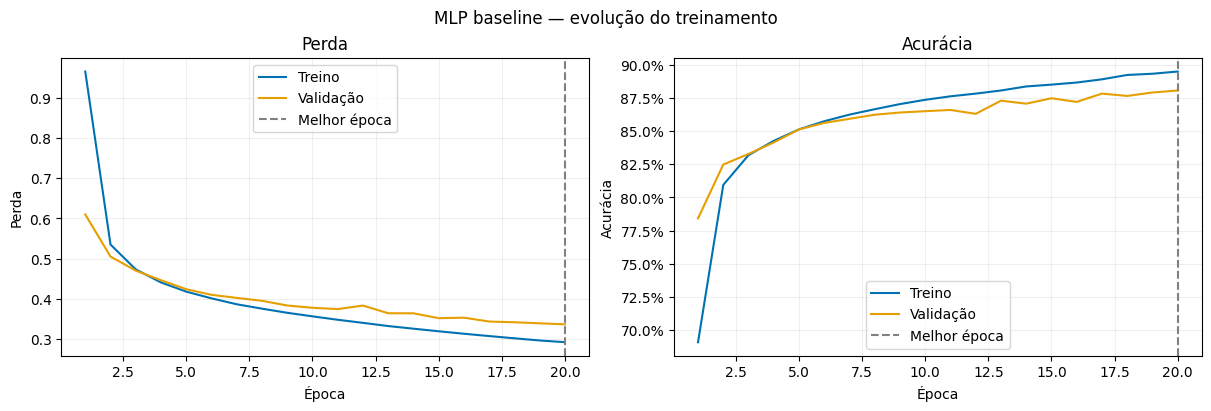

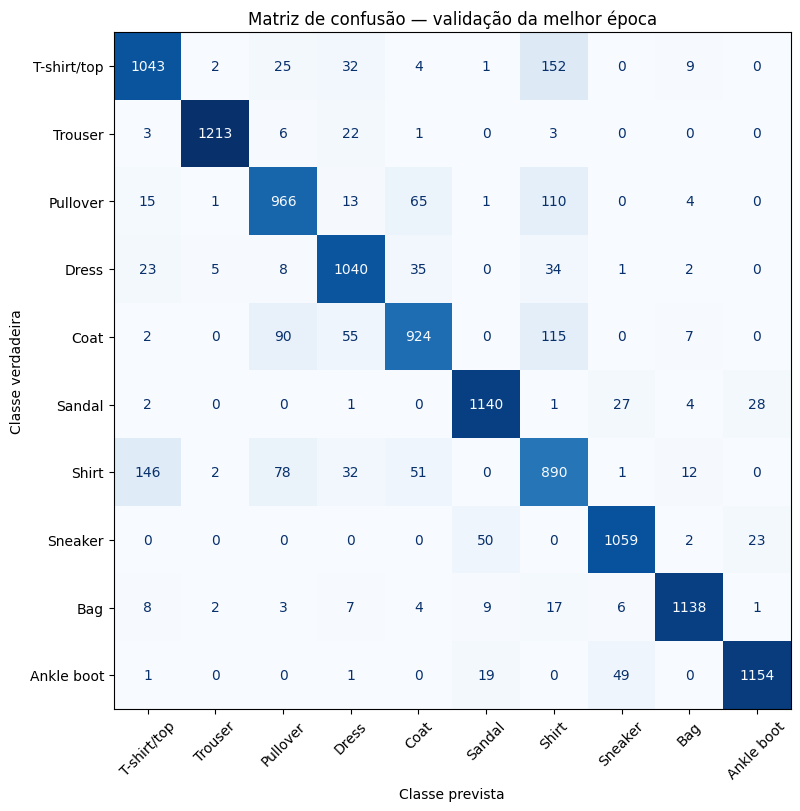

In [15]:
display(resultado_inicial["historico"])
display(pd.DataFrame(resultado_inicial["resumo"]["validacao"]["relatorio"]).T)
plotar_resultados(resultado_inicial, class_names)

### Avaliação da configuração inicial no teste

In [ ]:
#Usa o modelo da melhor época de validação, sem treinar novamente.
modelo_inicial = resultado_inicial["modelo"]
device_teste = next(modelo_inicial.parameters()).device

resultado_teste_inicial = avaliar_modelo(
    modelo_inicial,
    test_loader,
    nn.CrossEntropyLoss(),
    device_teste,
    nomes_classes=class_names,
)

print(f"Teste — configuração inicial (época {resultado_inicial['resumo']['melhor_epoca']})")
print(f"Perda: {resultado_teste_inicial['loss']:.4f}")
print(f"Acurácia: {resultado_teste_inicial['accuracy']:.2%}")
relatorio_teste = pd.DataFrame({
    nome: metricas
    for nome, metricas in resultado_teste_inicial["relatorio"].items()
    if isinstance(metricas, dict)
}).T
display(relatorio_teste)

arquivo_teste = resultado_inicial["output_dir"] / "teste_inicial.json"
arquivo_teste.write_text(
    json.dumps(resultado_teste_inicial, indent=2, ensure_ascii=False),
    encoding="utf-8",
)
print(f"Resultado salvo em: {arquivo_teste}")

Teste — configuração inicial (época 20)
Perda: 0.3635
Acurácia: 87.00%


,precision,recall,f1-score,support
T-shirt/top,0.843558,0.825,0.834176,1000.0
Trouser,0.989723,0.963,0.976178,1000.0
Pullover,0.778206,0.807,0.792342,1000.0
Dress,0.859496,0.887,0.873031,1000.0
Coat,0.829885,0.722,0.772193,1000.0
Sandal,0.935039,0.950,0.942460,1000.0
Shirt,0.647696,0.717,0.680589,1000.0
Sneaker,0.927565,0.922,0.924774,1000.0
Bag,0.966834,0.962,0.964411,1000.0
Ankle boot,0.946894,0.945,0.945946,1000.0


Resultado salvo em: C:\Users\davis\Documents\vscode\redesNeuraisUC\mlp_rn\results\classification\20260914_194031_968331\teste_inicial.json


### Comparação de treinamento online, mini-batch e em lote

Criamos uma cópia da `config_inicial`, chamada `config_batches`, com **10 épocas para os três regimes**. A configuração inicial usa 20 épocas. Entre os regimes, alteramos apenas o tamanho do lote: **1**, **64** e **48.000** (todo o treino). Cada execução reinicia os pesos com a mesma seed e mantém os mesmos subconjuntos de treino e validação.

Reduzimos para 10 épocas porque o treinamento online faz uma atualização por imagem e pode demorar muito com 20 épocas. Com 10 épocas, são respectivamente **480.000**, **7.500** e **10 atualizações** dos pesos. Portanto, o número de épocas é igual, mas o trabalho e os tempos são diferentes. Esta comparação não determina qual regime é sempre melhor: o learning rate permanece fixo e o treinamento em lote recebe apenas 10 atualizações. Os resultados são comparados pela validação.

In [ ]:
def comparar_batches(config, treino_ds, validacao_ds, nomes_classes, seed=42, device=None, output_dir=None):

    if output_dir is None:
        output_dir = BASE_DIR / "results" / "classification" / (
            "comparacao_batches_" + datetime.now().strftime("%Y%m%d_%H%M%S_%f")
        )
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    device = torch.device(device or ("cuda" if torch.cuda.is_available() else "cpu"))
    regimes = {"Online": 1, "Mini-batch": 64, "Em lote": len(treino_ds)}
    resultados, linhas = {}, []

    for nome, tamanho in regimes.items():
        config_batch = copy.deepcopy(config)
        config_batch["batch_size"] = tamanho
        print(f"\n=== {nome}: batch_size={tamanho} ===", flush=True)
        resultado = treinar_modelo(
            config_batch, treino_ds, validacao_ds, nomes_classes,
            seed=seed, device=device, output_dir=output_dir / f"batch_{tamanho}",
        )
        resultados[nome] = resultado
        resumo = resultado["resumo"]
        atualizacoes = math.ceil(len(treino_ds) / tamanho)
        linhas.append({
            "regime": nome, "batch_size": tamanho,
            "epochs": config_batch["epochs"],
            "atualizacoes_por_epoca": atualizacoes,
            "atualizacoes_totais": atualizacoes * config_batch["epochs"],
            "melhor_epoca": resumo["melhor_epoca"],
            "val_accuracy": resumo["validacao"]["accuracy"],
            "val_loss": resumo["validacao"]["loss"],
            "val_f1_macro": resumo["validacao"]["relatorio"]["macro avg"]["f1-score"],
            "tempo_segundos": resumo["duracao_segundos"],
        })
        pd.DataFrame(linhas).to_csv(output_dir / "comparacao.csv", index=False)

    tabela = pd.DataFrame(linhas).sort_values(
        ["val_accuracy", "val_loss"], ascending=[False, True]
    ).reset_index(drop=True)
    tabela.to_csv(output_dir / "comparacao.csv", index=False)
    print(f"\nMaior acurácia de validação nesta comparação: {tabela.iloc[0]['regime']}")
    print(f"Arquivos salvos em: {output_dir}")
    return {"resultados": resultados, "tabela": tabela, "output_dir": output_dir}

In [ ]:
def plotar_comparacao_batches(comparacao):
    fig, axes = plt.subplots(2, 2, figsize=(13, 8), layout="constrained")
    cores = ("#0072B2", "#E69F00", "#009E73")
    for cor, (nome, resultado) in zip(cores, comparacao["resultados"].items()):
        historico = resultado["historico"]
        for ax, coluna, titulo in zip(
            axes.flat,
            ("train_loss", "val_loss", "train_accuracy", "val_accuracy"),
            ("Perda — treino", "Perda — validação", "Acurácia — treino", "Acurácia — validação"),
        ):
            ax.plot(historico["epoch"], historico[coluna], label=nome, color=cor)
            ax.set(title=titulo, xlabel="Época")
            if "accuracy" in coluna:
                ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
                ax.set_ylim(0, 1)
            ax.grid(alpha=0.2)
    for ax in axes.flat:
        ax.legend()
    fig.suptitle("Comparação de lotes — mesma arquitetura, learning rate e épocas")
    for ext in ("png", "pdf"):
        fig.savefig(comparacao["output_dir"] / f"comparacao_curvas.{ext}",
                    dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)


=== Online: batch_size=1 ===
Dispositivo: cuda | Configuração: {'arquitetura': [128, 64], 'ativacao': 'relu', 'learning_rate': 0.01, 'batch_size': 1, 'epochs': 10, 'optimizer': 'sgd'}
Época 01/10 | treino: perda=0.5206, acurácia=80.98% | validação: perda=0.4227, acurácia=84.42%
Época 02/10 | treino: perda=0.4057, acurácia=85.22% | validação: perda=0.3895, acurácia=85.89%
Época 03/10 | treino: perda=0.3718, acurácia=86.43% | validação: perda=0.4467, acurácia=82.89%
Época 04/10 | treino: perda=0.3451, acurácia=87.53% | validação: perda=0.4075, acurácia=86.36%
Época 05/10 | treino: perda=0.3310, acurácia=87.85% | validação: perda=0.3902, acurácia=86.42%
Época 06/10 | treino: perda=0.3231, acurácia=88.14% | validação: perda=0.4199, acurácia=86.61%
Época 07/10 | treino: perda=0.3042, acurácia=88.68% | validação: perda=0.3762, acurácia=86.83%
Época 08/10 | treino: perda=0.2947, acurácia=89.16% | validação: perda=0.3646, acurácia=87.73%
Época 09/10 | treino: perda=0.2885, acurácia=89.42% | v

,regime,batch_size,epochs,atualizacoes_por_epoca,atualizacoes_totais,melhor_epoca,val_accuracy,val_loss,val_f1_macro,tempo_segundos
0,Online,1,10,48000,480000,8,87.73%,0.3646,0.8742,952.2
1,Mini-batch,64,10,750,7500,10,86.50%,0.3777,0.8635,23.1
2,Em lote,48000,10,1,10,10,17.67%,2.2661,0.0792,7.5


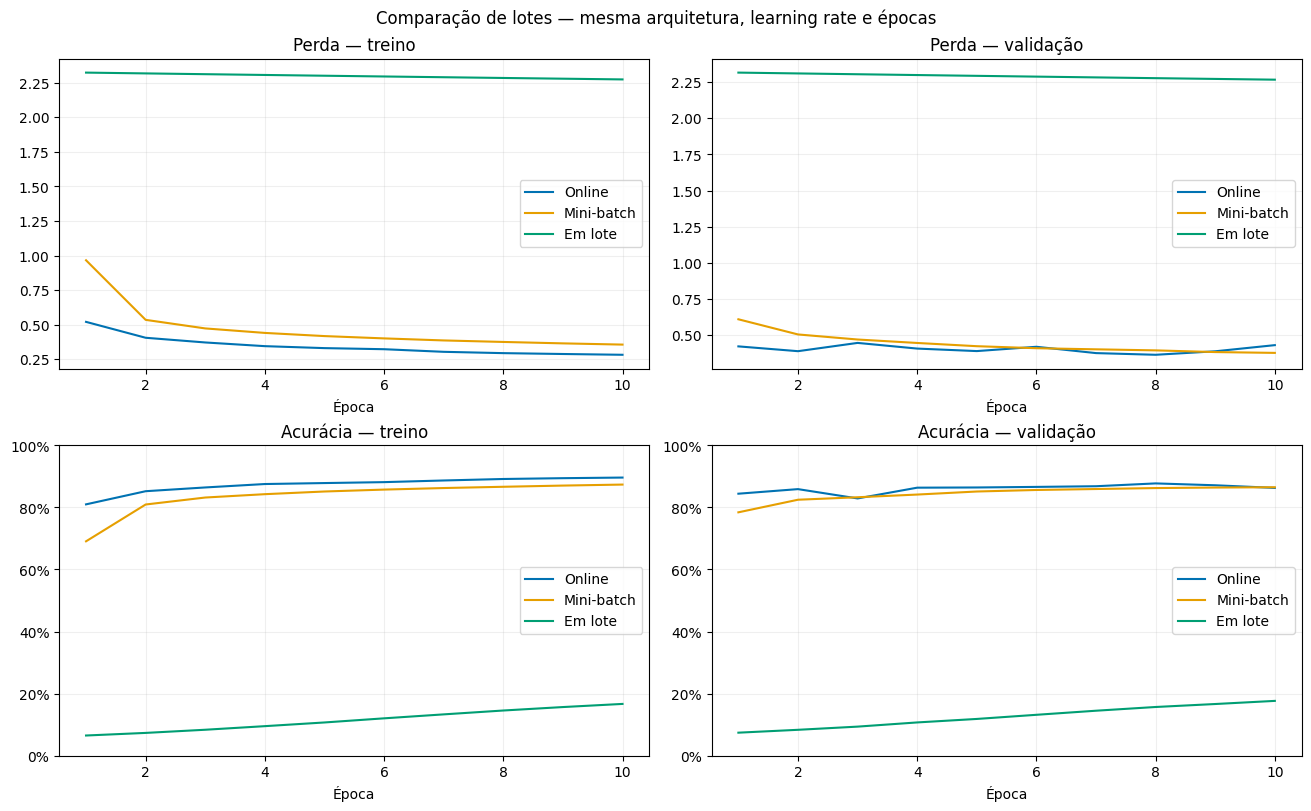

In [19]:
config_batches = copy.deepcopy(config_inicial)
config_batches["epochs"] = 10

comparacao_batches = comparar_batches(
    config_batches,
    treino_ds=train_loader.dataset,
    validacao_ds=val_loader.dataset,
    nomes_classes=class_names,
    seed=SEED,
)
display(comparacao_batches["tabela"].style.format({
    "val_accuracy": "{:.2%}", "val_loss": "{:.4f}",
    "val_f1_macro": "{:.4f}", "tempo_segundos": "{:.1f}",
}))
plotar_comparacao_batches(comparacao_batches)

### Testar hiperparâmetros para achar o melhor modelo baseline

O **Optuna** automatiza a busca de hiperparâmetros. Cada tentativa (*trial*) monta uma configuração, treina uma MLP nova e mede sua melhor acurácia de validação. O algoritmo TPE usa os resultados anteriores para orientar novas sugestões. O SGD continua sendo o otimizador dos pesos, já que o Optuna escolhe apenas os hiperparâmetros, mantendo a ideia do baseline. [Documentação](https://optuna.org/)

Começamos com **20 tentativas de 20 épocas**, buscando 1 a 3 camadas, 64/128/256 neurônios por camada, ReLU/Tanh/Sigmoid, learning rate entre 0,001 e 0,1 e mini-batches de 32/64/128/256. 

In [5]:
import optuna

In [6]:
#Monta a configuração de hiperparâmetros de uma tentativa, com base em uma sugestão do Optuna.
def sugerir_config(trial, config_base, epochs):
    config = copy.deepcopy(config_base)
    n_camadas = trial.suggest_int("n_camadas", 1, 3)
    config["arquitetura"] = [
        trial.suggest_categorical(f"neuronios_{i}", [64, 128, 256])
        for i in range(n_camadas)
    ]
    config["ativacao"] = trial.suggest_categorical("ativacao", ["relu", "tanh", "sigmoid"])
    config["learning_rate"] = trial.suggest_float("learning_rate", 0.001, 0.1, log=True)
    config["batch_size"] = trial.suggest_categorical("batch_size", [32, 64, 128, 256])
    config["epochs"] = epochs
    config["optimizer"] = "sgd"
    return config

In [4]:
#Organiza e executa a busca de hiperparâmetros com o Optuna, salvando resultados em disco.
def buscar_hiperparametros(config_base, treino_ds, validacao_ds, nomes_classes, n_trials=20, epochs=20, seed=42, device=None):
    if type(n_trials) is not int or n_trials <= 0:
        raise ValueError("n_trials deve ser um inteiro positivo.")
    if type(epochs) is not int or epochs <= 0:
        raise ValueError("epochs deve ser um inteiro positivo.")
    from shutil import copy2

    pasta = BASE_DIR / "results" / "classification" / (
        "optuna_" + datetime.now().strftime("%Y%m%d_%H%M%S_%f")
    )
    pasta.mkdir(parents=True, exist_ok=True)

    #Chama sugerir_config() para cada tentativa, treina o modelo e retorna a acurácia de validação.
    def objetivo(trial):
        config = sugerir_config(trial, config_base, epochs)
        trial.set_user_attr("config", config)
        trial.set_user_attr("seed", seed)
        pasta_trial = pasta / f"trial_{trial.number:03d}"
        trial.set_user_attr("output_dir", str(pasta_trial))
        resultado = treinar_modelo(
            config, treino_ds, validacao_ds, nomes_classes, seed=seed, device=device, output_dir=pasta_trial, verbose=False,
        )
        resumo = resultado["resumo"]
        trial.set_user_attr("melhor_epoca", resumo["melhor_epoca"])
        trial.set_user_attr("val_loss", resumo["validacao"]["loss"])
        trial.set_user_attr("duracao_segundos", resumo["duracao_segundos"])
        #A rede de cada tentativa fica salva em disco, sem acumular modelos na GPU.
        return resumo["validacao"]["accuracy"]

    #Cria o estudo do Optuna, que vai sugerir as configurações
    nivel_logs = optuna.logging.get_verbosity()
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    try:
        estudo = optuna.create_study(
            study_name="baseline_classificacao",
            direction="maximize",
            sampler=optuna.samplers.TPESampler(seed=seed),
            pruner=optuna.pruners.NopPruner(),
            storage="sqlite:///" + (pasta / "estudo.db").as_posix(),
        )

        #Organiza a primeira tentativa com a configuração inicial, para ter um baseline.
        arquitetura = config_base["arquitetura"]
        if (1 <= len(arquitetura) <= 3 and all(n in [64, 128, 256] for n in arquitetura)
            and config_base["ativacao"] in ["relu", "tanh", "sigmoid"]
            and config_base["batch_size"] in [32, 64, 128, 256]
            and 0.001 <= config_base["learning_rate"] <= 0.1):
            parametros_iniciais = {
                "n_camadas": len(arquitetura), 
                "ativacao": config_base["ativacao"],
                "learning_rate": config_base["learning_rate"],
                "batch_size": config_base["batch_size"],
                **{f"neuronios_{i}": n for i, n in enumerate(arquitetura)},
            }
            estudo.enqueue_trial(parametros_iniciais)

        def salvar_tabela(estudo, trial):
            estudo.trials_dataframe().to_csv(pasta / "tentativas.csv", index=False)
            print(
                f"Tentativa {trial.number + 1}/{n_trials} | "
                f"Melhor época: {trial.user_attrs['melhor_epoca']} | "
                f"Validação: {trial.value:.2%} | Config: {trial.user_attrs['config']}",
                flush=True,
            )

        #Uma tentativa por vez para não disputar a GPU e para controlar a seed.
        estudo.optimize(objetivo, n_trials=n_trials, n_jobs=1, callbacks=[salvar_tabela], gc_after_trial=True)
    finally:
        optuna.logging.set_verbosity(nivel_logs)


    #Salva a configuração da melhor tentativa em JSON.
    melhor_trial = estudo.best_trial
    melhor_config = copy.deepcopy(melhor_trial.user_attrs["config"])
    (pasta / "melhor_config.json").write_text(json.dumps(melhor_config, indent=2, ensure_ascii=False), encoding="utf-8")
    pasta_best = BASE_DIR / "results" / "classification" / "optuna_best"
    pasta_best.mkdir(parents=True, exist_ok=True)
    copy2(Path(melhor_trial.user_attrs["output_dir"]) / "melhor_modelo.pt",
          pasta_best / "melhor_modelo.pt")
    copy2(pasta / "melhor_config.json", pasta_best / "melhor_config.json")
    (pasta_best / "origem.json").write_text(json.dumps({
        "estudo_dir": str(pasta), "trial": melhor_trial.number, "acuracia_validacao": melhor_trial.value,
    }, indent=2, ensure_ascii=False), encoding="utf-8")

    #A comparação usa a configuração inicial com o mesmo número de épocas.
    config_comparacao = copy.deepcopy(config_base)
    config_comparacao["epochs"] = epochs
    inicial = next((t for t in estudo.trials
                    if t.state == optuna.trial.TrialState.COMPLETE
                    and t.user_attrs.get("config") == config_comparacao), None)
    if inicial is not None:
        modelo_inicial_path = Path(inicial.user_attrs["output_dir"]) / "melhor_modelo.pt"
        acuracia_inicial = inicial.value
    else:
        resultado = treinar_modelo(
            config_comparacao, treino_ds, validacao_ds, nomes_classes, seed=seed, device=device, output_dir=pasta / "modelo_inicial", verbose=False,
        )
        modelo_inicial_path = resultado["output_dir"] / "melhor_modelo.pt"
        acuracia_inicial = resultado["resumo"]["validacao"]["accuracy"]

    return {
        "estudo": estudo, "melhor_config": melhor_config, "output_dir": pasta,
        "melhor_modelo_path": pasta_best / "melhor_modelo.pt",
        "modelo_inicial_path": modelo_inicial_path,
        "acuracia_inicial": acuracia_inicial,
    }

In [22]:
N_TRIALS = 20
EPOCHS_OPTUNA = 20

busca_optuna = buscar_hiperparametros(
    config_inicial,
    treino_ds=train_loader.dataset,
    validacao_ds=val_loader.dataset,
    nomes_classes=class_names,
    n_trials=N_TRIALS,
    epochs=EPOCHS_OPTUNA,
    seed=SEED,
)
melhor_config_optuna = busca_optuna["melhor_config"]
optuna_best = {
    "config": copy.deepcopy(busca_optuna["melhor_config"]),
    "checkpoint": busca_optuna["melhor_modelo_path"],
}
print(f"Melhor modelo salvo em: {optuna_best['checkpoint']}")


Tentativa 1/20 | Melhor época: 20 | Validação: 88.06% | Config: {'arquitetura': [128, 64], 'ativacao': 'relu', 'learning_rate': 0.01, 'batch_size': 64, 'epochs': 20, 'optimizer': 'sgd'}
Tentativa 2/20 | Melhor época: 19 | Validação: 84.67% | Config: {'arquitetura': [64, 64], 'ativacao': 'relu', 'learning_rate': 0.0010994335574766201, 'batch_size': 32, 'epochs': 20, 'optimizer': 'sgd'}
Tentativa 3/20 | Melhor época: 19 | Validação: 84.55% | Config: {'arquitetura': [128], 'ativacao': 'tanh', 'learning_rate': 0.00383962929980417, 'batch_size': 128, 'epochs': 20, 'optimizer': 'sgd'}
Tentativa 4/20 | Melhor época: 20 | Validação: 86.09% | Config: {'arquitetura': [256, 256], 'ativacao': 'relu', 'learning_rate': 0.0015679933916723015, 'batch_size': 32, 'epochs': 20, 'optimizer': 'sgd'}
Tentativa 5/20 | Melhor época: 20 | Validação: 82.63% | Config: {'arquitetura': [64], 'ativacao': 'sigmoid', 'learning_rate': 0.0023426581058204046, 'batch_size': 32, 'epochs': 20, 'optimizer': 'sgd'}
Tentativa

In [23]:
melhor_trial = busca_optuna["estudo"].best_trial
print(f"Melhor tentativa: {melhor_trial.number + 1}")
print(f"Acurácia de validação: {melhor_trial.value:.2%}")
print(f"Melhor época: {melhor_trial.user_attrs['melhor_epoca']}")
print(f"Configuração: {optuna_best['config']}")
print(f"Configuração inicial com as mesmas épocas: {busca_optuna['acuracia_inicial']:.2%}")
print(f"Diferença: {(melhor_trial.value - busca_optuna['acuracia_inicial']) * 100:+.2f} p.p.")

Melhor tentativa: 15
Acurácia de validação: 89.83%
Melhor época: 20
Configuração: {'arquitetura': [256, 256, 256], 'ativacao': 'relu', 'learning_rate': 0.05821445965092194, 'batch_size': 64, 'epochs': 20, 'optimizer': 'sgd'}
Configuração inicial com as mesmas épocas: 88.06%
Diferença: +1.77 p.p.


### Comparação no teste: modelo inicial e melhor modelo do Optuna

Comparamos **acurácia, precisão, recall e F1**.


In [24]:
def avaliar_checkpoint(caminho, loader, nomes_classes, device=None):
    """Carrega os melhores pesos salvos e avalia as mesmas imagens de teste."""
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

    device = torch.device(device or ("cuda" if torch.cuda.is_available() else "cpu"))
    checkpoint = torch.load(caminho, map_location="cpu", weights_only=True)
    if list(checkpoint["class_names"]) != list(nomes_classes):
        raise ValueError("A ordem das classes do modelo difere da ordem do dataset.")
    modelo = criar_modelo_baseline(checkpoint["config"], len(nomes_classes)).to(device)
    modelo.load_state_dict(checkpoint["model_state_dict"])
    modelo.eval()
    previsoes, rotulos = [], []
    with torch.no_grad():
        for imagens, alvos in loader:
            previsoes.append(modelo(imagens.to(device)).argmax(dim=1).cpu())
            rotulos.append(alvos.cpu())
    previsoes = torch.cat(previsoes).numpy()
    rotulos = torch.cat(rotulos)
    rotulos = rotulos.numpy()
    labels = list(range(len(nomes_classes)))
    metricas = {
        "Acurácia": accuracy_score(rotulos, previsoes),
        "Precisão": precision_score(rotulos, previsoes, labels=labels, average="macro", zero_division=0),
        "Recall": recall_score(rotulos, previsoes, labels=labels, average="macro", zero_division=0),
        "F1": f1_score(rotulos, previsoes, labels=labels, average="macro", zero_division=0),
    }
    metadados = {
        "checkpoint": str(caminho), "config": checkpoint["config"],
        "melhor_epoca": checkpoint["epoch"], "seed": checkpoint["seed"],
        "amostras_teste": len(rotulos), "classes": list(nomes_classes),
    }
    return metricas, metadados


In [25]:
checkpoints_comparacao = {
    "Modelo inicial": busca_optuna["modelo_inicial_path"],
    "Melhor Optuna": optuna_best["checkpoint"],
}

metricas_comparacao, detalhes_comparacao = {}, {}
for nome, caminho in checkpoints_comparacao.items():
    metricas_comparacao[nome], detalhes_comparacao[nome] = avaliar_checkpoint(
        caminho, test_loader, class_names,
    )

tabela_comparacao_modelos = pd.DataFrame.from_dict(metricas_comparacao, orient="index")
print("Métricas de classificação — conjunto de teste")
display(tabela_comparacao_modelos.style.format("{:.2%}"))

pasta_comparacao_modelos = BASE_DIR / "results/classification/comparacao_inicial_optuna"
pasta_comparacao_modelos.mkdir(parents=True, exist_ok=True)
tabela_comparacao_modelos.to_csv(pasta_comparacao_modelos / "metricas_teste.csv", index_label="Modelo")
(pasta_comparacao_modelos / "detalhes.json").write_text(
    json.dumps(detalhes_comparacao, indent=2, ensure_ascii=False), encoding="utf-8"
)
print(f"Resultados salvos em: {pasta_comparacao_modelos}")

Métricas de classificação — conjunto de teste


,Acurácia,Precisão,Recall,F1
Modelo inicial,87.00%,87.25%,87.00%,87.06%
Melhor Optuna,88.54%,88.71%,88.54%,88.60%


Resultados salvos em: C:\Users\davis\Documents\vscode\redesNeuraisUC\mlp_rn\results\classification\comparacao_inicial_optuna


## 3. Estudo de Ablação

Comparamos **baseline**, **baseline + L1**, **baseline + L2**, **baseline + dropout** e **baseline + momentum**.

Usamos a melhor configuração da busca atual do Optuna, com 20 épocas. Todos os casos começam do zero com a mesma seed, os mesmos pesos iniciais das camadas lineares e a mesma divisão dos dados.

Valores iniciais das técnicas: **L1 = 0,000001**, **L2 = 0,0001**, **dropout = 0,20** e **momentum = 0,90**. São escolhas iniciais, não valores otimizados.

As métricas de treino são acumuladas durante as atualizações, com dropout ativo quando utilizado. A validação é avaliada ao final de cada época, com dropout desligado. As perdas das curvas são de classificação, sem a penalidade adicional.

In [26]:
#Função para criar um modelo, semelhante ao do baseline, mas agora podendo incluir L1, L2, Dropout e Momentum.
def criar_modelo_ablacao(config, num_classes=10):
    #Verifica se os hiperparâmetros estão dentro dos limites esperados.
    for nome in ("l1", "l2"):
        if not math.isfinite(config.get(nome, 0.0)) or config.get(nome, 0.0) < 0:
            raise ValueError(f"{nome} deve ser positivo ou zero.")
    for nome in ("dropout", "momentum"):
        if not 0 <= config.get(nome, 0.0) < 1:
            raise ValueError(f"{nome} deve estar entre 0 (inclusive) e 1 (exclusive).")
    modelo = criar_modelo_baseline(config, num_classes)
    #Caso o dropout seja maior que zero, insere uma camada de Dropout após cada ativação.
    if config.get("dropout", 0.0) == 0:
        return modelo
    camadas = []
    for camada in modelo:
        camadas.append(camada)
        if isinstance(camada, (nn.ReLU, nn.Tanh, nn.Sigmoid)):
            camadas.append(nn.Dropout(config["dropout"]))
    return nn.Sequential(*camadas)

In [27]:
#Utilizado pelo L1 e L2, calculando um valor extra a ser somado ao erro do modelo.
#Pode ser útil para reduzir overfitting.
def penalidade_ablacao(modelo, config):
    penalidade = next(modelo.parameters()).new_zeros(())
    for camada in modelo.modules():
        if isinstance(camada, nn.Linear):
            if config.get("l1", 0.0):
                penalidade = penalidade + config["l1"] * camada.weight.abs().sum()
            if config.get("l2", 0.0):
                penalidade = penalidade + 0.5 * config["l2"] * camada.weight.square().sum()
    return penalidade

In [28]:
#Função para treinar o modelo, semelhante ao baseline.
def treinar_ablacao(config, treino_ds, validacao_ds, nomes_classes, seed=42, device=None, output_dir=None, verbose=True):

    #Cria o modelo, de acordo com a configuração.
    config = copy.deepcopy(config)
    if len(treino_ds) == 0 or len(validacao_ds) == 0:
        raise ValueError("Treino e validação precisam conter imagens.")
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"
    device = torch.device(device)
    torch.manual_seed(seed)
    modelo = criar_modelo_ablacao(config, num_classes=len(nomes_classes)).to(device)
    criterio = nn.CrossEntropyLoss()

    #Caso o momentum seja maior que zero, utiliza SGD com momentum.
    otimizador = torch.optim.SGD(
        modelo.parameters(),
        lr=config["learning_rate"],
        momentum=config.get("momentum", 0.0),
        weight_decay=0.0
    )

    #Carrega os dados de treino e validação.
    loader_treino = DataLoader(
        treino_ds,
        batch_size=config["batch_size"],
        shuffle=True,
        generator=torch.Generator().manual_seed(seed),
    )
    loader_validacao = DataLoader(
        validacao_ds,
        batch_size=config["batch_size"],
        shuffle=False
    )

    if output_dir is None:
        output_dir = BASE_DIR / "results" / "classification" / datetime.now().strftime("%Y%m%d_%H%M%S_%f")
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    historico = []
    melhor_acuracia, melhor_perda = -1.0, float("inf")
    melhor_epoca, melhores_pesos = None, None
    inicio = perf_counter()

    if verbose:
        print(f"Dispositivo: {device} | Configuração: {config}", flush=True)

    #Treina o modelo por um número definido de épocas, salvando o melhor modelo com base na acurácia nos dados de validação.
    for epoca in range(1, config["epochs"] + 1):
        modelo.train()
        perda_total, acertos, total = 0.0, 0, 0

        for imagens, alvos in loader_treino:
            imagens, alvos = imagens.to(device), alvos.to(device)

            otimizador.zero_grad(set_to_none=True)

            saidas = modelo(imagens)

            perda_dados = criterio(saidas, alvos)
            penalidade = penalidade_ablacao(modelo, config)
            perda = perda_dados + penalidade

            if not torch.isfinite(perda).item():
                raise ValueError("A perda deixou de ser finita; revise o learning rate.")

            perda.backward()
            otimizador.step()

            total += alvos.size(0)
            perda_total += perda_dados.item() * alvos.size(0)
            acertos += (saidas.argmax(dim=1) == alvos).sum().item()

        train_loss = perda_total / total
        train_accuracy = acertos / total

        validacao = avaliar_modelo(modelo, loader_validacao, criterio, device)

        if not math.isfinite(validacao["loss"]):
            raise ValueError("A perda de validação deixou de ser finita.")

        historico.append({
            "epoch": epoca,
            "train_loss": train_loss,
            "train_accuracy": train_accuracy,
            "val_loss": validacao["loss"],
            "val_accuracy": validacao["accuracy"],
        })

        if (
            validacao["accuracy"] > melhor_acuracia
            or (
                validacao["accuracy"] == melhor_acuracia
                and validacao["loss"] < melhor_perda
            )
        ):
            melhor_acuracia, melhor_perda = validacao["accuracy"], validacao["loss"]
            melhor_epoca = epoca
            melhores_pesos = {
                nome: valor.detach().cpu().clone()
                for nome, valor in modelo.state_dict().items()
            }

        if verbose:
            print(
                f"Época {epoca:02d}/{config['epochs']} | "
                f"treino: perda={train_loss:.4f}, acurácia={train_accuracy:.2%} | "
                f"validação: perda={validacao['loss']:.4f}, acurácia={validacao['accuracy']:.2%}",
                flush=True
            )

    pd.DataFrame(historico).to_csv(
        output_dir / "historico.csv",
        index=False
    )

    torch.save({
        "model_state_dict": melhores_pesos,
        "config": config,
        "seed": seed,
        "class_names": list(nomes_classes),
        "epoch": melhor_epoca,
        "val_accuracy": melhor_acuracia,
        "val_loss": melhor_perda
    }, output_dir / "melhor_modelo.pt")

    modelo.load_state_dict(melhores_pesos)
    modelo.eval()

    avaliacao = avaliar_modelo(
        modelo,
        loader_validacao,
        criterio,
        device,
        nomes_classes
    )

    resumo = {
        "config": config,
        "seed": seed,
        "device": str(device),
        "train_size": len(treino_ds),
        "val_size": len(validacao_ds),
        "melhor_epoca": melhor_epoca,
        "duracao_segundos": perf_counter() - inicio,
        "validacao": avaliacao,
    }

    (output_dir / "resultado.json").write_text(
        json.dumps(resumo, indent=2, ensure_ascii=False),
        encoding="utf-8"
    )

    if verbose:
        print(f"Melhor época: {melhor_epoca} | Validação: {avaliacao['accuracy']:.2%}")
        print(f"Resultados salvos em: {output_dir}")

    return {
        "modelo": modelo,
        "historico": pd.DataFrame(historico),
        "resumo": resumo,
        "output_dir": output_dir
    }

In [29]:
#Organiza e executa todos os casos, comparando com o baseline, sem consultar o teste.
def executar_ablacoes(config_base, treino_ds, validacao_ds, nomes_classes,l1=1e-6, l2=1e-4, dropout=0.2, momentum=0.9, seed=42, device=None, output_dir=None, casos=None):
    if output_dir is None:
        output_dir = BASE_DIR / "results" / "classification" / (
            "ablacao_" + datetime.now().strftime("%Y%m%d_%H%M%S_%f")
        )
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    if casos is None:
        casos = {
            "Baseline": {}, 
            "Baseline + L1": {"l1": l1},
            "Baseline + L2": {"l2": l2}, 
            "Baseline + dropout": {"dropout": dropout},
            "Baseline + momentum": {"momentum": momentum},
        }
    resultados, linhas = {}, []
    for i, (nome, tecnica) in enumerate(casos.items()):
        config = copy.deepcopy(config_base)
        config.update(l1=0.0, l2=0.0, dropout=0.0, momentum=0.0)
        config.update(tecnica)
        print(f"Iniciando {nome} ({i + 1}/{len(casos)})...", flush=True)
        resultado = treinar_ablacao(
            config, treino_ds, validacao_ds, nomes_classes, seed=seed, device=device, output_dir=output_dir / f"caso_{i}", verbose=False,
        )
        resultados[nome] = resultado
        resumo = resultado["resumo"]
        metricas = resumo["validacao"]
        medias = metricas["relatorio"]["macro avg"]
        linhas.append({
            "Modelo": nome, 
            "Acurácia": metricas["accuracy"],
            "Precisão": medias["precision"], 
            "Recall": medias["recall"],
            "F1": medias["f1-score"], 
            "Melhor época": resumo["melhor_epoca"],
            "Tempo (s)": resumo["duracao_segundos"],
        })
        pd.DataFrame(linhas).to_csv(output_dir / "comparacao_validacao.csv", index=False)
        print(f"{nome} | melhor época: {resumo['melhor_epoca']} | "
              f"validação: {metricas['accuracy']:.2%}", flush=True)
    return {"resultados": resultados, "tabela": pd.DataFrame(linhas), "output_dir": output_dir}

In [30]:
def plotar_ablacoes(ablacoes):
    """Barras das métricas e curvas de acurácia, salvas em PNG e PDF."""
    tabela = ablacoes["tabela"]
    cores = ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#D55E00"]
    rotulos = [nome.replace("Baseline + ", "+ ") for nome in tabela["Modelo"]]
    muitos_casos = len(tabela) > 5
    cores = [cores[i % len(cores)] for i in range(len(tabela))]
    fig, axes = plt.subplots(2, 2, figsize=(18, 14) if muitos_casos else (12, 8), layout="constrained")
    for ax, metrica in zip(axes.flat, ("Acurácia", "Precisão", "Recall", "F1")):
        if muitos_casos:
            barras = ax.barh(rotulos, tabela[metrica], color=cores, zorder=3)
            ax.invert_yaxis()
            ax.set(title=metrica, xlim=(0, 1.12))
            ax.xaxis.set_major_formatter(PercentFormatter(xmax=1))
            ax.grid(axis="x", alpha=0.2, zorder=0)
        else:
            barras = ax.bar(rotulos, tabela[metrica], color=cores, zorder=3)
            ax.set(title=metrica, ylim=(0, 1.08))
            ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
            ax.grid(axis="y", alpha=0.2, zorder=0)
        ax.bar_label(barras, labels=[f"{valor:.2%}" for valor in tabela[metrica]], padding=3, fontsize=9)
    fig.suptitle("Ablação — métricas de validação da melhor época de cada modelo")
    for ext in ("png", "pdf"):
        fig.savefig(ablacoes["output_dir"] / f"metricas_ablacao.{ext}", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    n_colunas = 4 if muitos_casos else 3
    n_linhas = math.ceil(len(tabela) / n_colunas)
    fig, axes = plt.subplots(n_linhas, n_colunas, figsize=(20, 14) if muitos_casos else (14, 8),
                             layout="constrained", sharex=True, sharey=True, squeeze=False)
    for ax, (nome, resultado) in zip(axes.flat, ablacoes["resultados"].items()):
        historico = resultado["historico"]
        ax.plot(historico["epoch"], historico["train_accuracy"], label="Treino", color="#0072B2")
        ax.plot(historico["epoch"], historico["val_accuracy"], label="Validação", color="#E69F00")
        ax.axvline(resultado["resumo"]["melhor_epoca"], linestyle="--", color="gray", label="Melhor época")
        ax.set(title=nome, xlabel="Época", ylabel="Acurácia", ylim=(0, 1))
        ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
        ax.grid(alpha=0.2)
        ax.legend(fontsize=9)
    for ax in list(axes.flat)[len(tabela):]:
        ax.axis("off")
    fig.suptitle("Ablação — acurácia de treino e validação ao final de cada época")
    for ext in ("png", "pdf"):
        fig.savefig(ablacoes["output_dir"] / f"curvas_ablacao.{ext}", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

In [31]:
# Usa a configuração vencedora da busca atual.
config_ablacao = copy.deepcopy(optuna_best["config"])
config_ablacao["epochs"] = 20

resultado_ablacoes = executar_ablacoes(
    config_ablacao,
    treino_ds=train_loader.dataset,
    validacao_ds=val_loader.dataset,
    nomes_classes=class_names,
    l1=1e-6, l2=1e-4, dropout=0.2, momentum=0.9,
    seed=SEED,
)

Iniciando Baseline (1/5)...
Baseline | melhor época: 20 | validação: 89.83%
Iniciando Baseline + L1 (2/5)...
Baseline + L1 | melhor época: 17 | validação: 89.56%
Iniciando Baseline + L2 (3/5)...
Baseline + L2 | melhor época: 20 | validação: 89.74%
Iniciando Baseline + dropout (4/5)...
Baseline + dropout | melhor época: 15 | validação: 89.49%
Iniciando Baseline + momentum (5/5)...
Baseline + momentum | melhor época: 14 | validação: 89.03%


,Modelo,Acurácia,Precisão,Recall,F1,Melhor época,Tempo (s)
0,Baseline,89.83%,89.88%,89.86%,89.84%,20,39.1
1,Baseline + L1,89.56%,89.52%,89.59%,89.53%,17,52.9
2,Baseline + L2,89.74%,89.77%,89.77%,89.76%,20,55.2
3,Baseline + dropout,89.49%,89.48%,89.51%,89.43%,15,43.9
4,Baseline + momentum,89.03%,89.09%,89.01%,89.00%,14,38.9


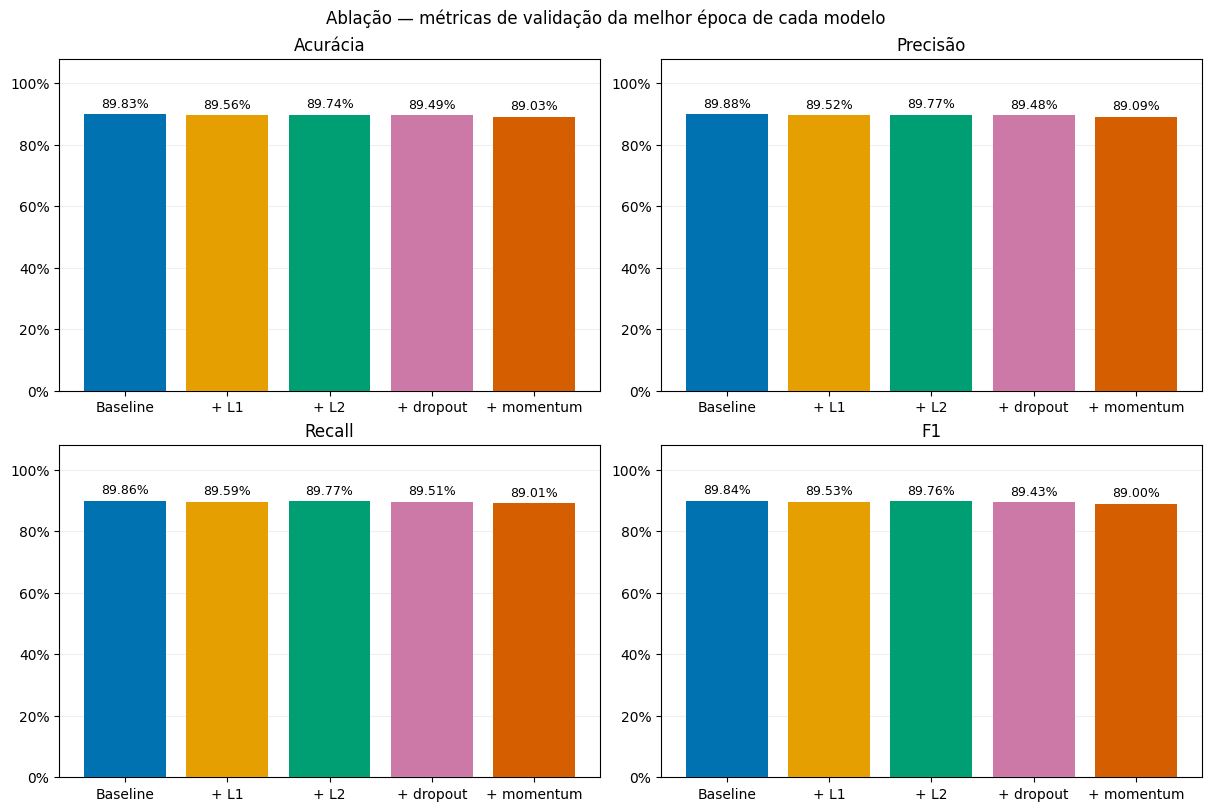

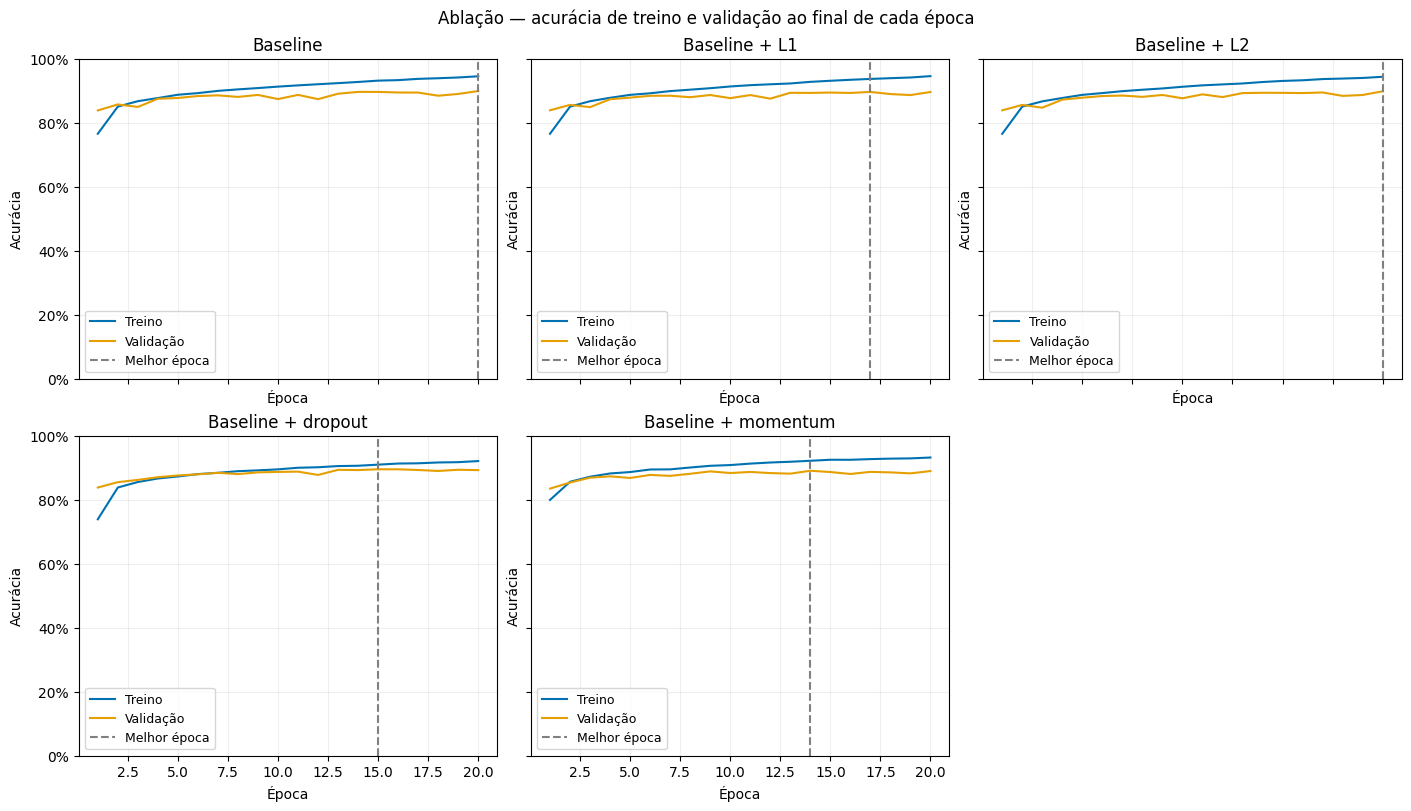

In [32]:
display(resultado_ablacoes["tabela"].style.format({
    "Acurácia": "{:.2%}", "Precisão": "{:.2%}", "Recall": "{:.2%}",
    "F1": "{:.2%}", "Tempo (s)": "{:.1f}",
}))
plotar_ablacoes(resultado_ablacoes)

## 4. Otimização individual das técnicas

Antes de combinar as técnicas, testamos **quatro valores de cada uma**, sempre adicionando apenas essa técnica ao baseline escolhido. É uma busca em grade pequena: **16 configurações mais o baseline**, totalizando 17 treinamentos.

Mantemos a arquitetura, ativação, learning rate, batch size, divisão dos dados e seed. Usamos **20 épocas em todos os casos**, incluindo o baseline, para controlar o custo e manter o mesmo orçamento do tópico 5.

Valores iniciais da busca, editáveis na célula abaixo:

- **L1:** `1e-7`, `1e-6`, `1e-5`, `1e-4`.
- **L2:** `1e-5`, `1e-4`, `1e-3`, `1e-2`.
- **Dropout:** `0.1`, `0.2`, `0.3`, `0.5`.
- **Momentum:** `0.3`, `0.5`, `0.7`, `0.9`.

Escolhemos o melhor valor de cada técnica pela maior acurácia de validação, com desempate pela menor perda de validação. A tabela mostra também a diferença em relação ao baseline. Os gráficos mostram as quatro métricas por valor, com referência à acurácia do baseline. Precisão, recall e F1 dão o mesmo peso a cada classe. Utilizaremos 20 épocas.

In [33]:
def otimizar_tecnicas(config_base, valores, treino_ds, validacao_ds, nomes_classes,
                     seed=42, device=None, output_dir=None):
    """Testa cada intensidade isoladamente e escolhe pela validação."""
    nomes = {"l1": "L1", "l2": "L2", "dropout": "dropout", "momentum": "momentum"}
    if set(valores) != set(nomes):
        raise ValueError("Informe valores para l1, l2, dropout e momentum.")
    for tecnica, opcoes in valores.items():
        if len(opcoes) != 4 or len(set(opcoes)) != 4:
            raise ValueError(f"Informe quatro valores distintos para {tecnica}.")
        for valor in opcoes:
            if not math.isfinite(valor) or valor <= 0:
                raise ValueError("Use valores positivos e finitos; o baseline já representa zero.")
            if tecnica in ("dropout", "momentum") and valor >= 1:
                raise ValueError(f"{tecnica} deve ser menor que 1.")
    if output_dir is None:
        output_dir = BASE_DIR / "results/classification" / (
            "otimizacao_tecnicas_" + datetime.now().strftime("%Y%m%d_%H%M%S_%f")
        )
    casos = {"Baseline": {}}
    identificacao = {}
    for tecnica, opcoes in valores.items():
        for valor in opcoes:
            nome = f"Baseline + {nomes[tecnica]} ({valor:g})"
            casos[nome] = {tecnica: valor}
            identificacao[nome] = (tecnica, valor)
    execucao = executar_ablacoes(
        config_base, treino_ds, validacao_ds, nomes_classes,
        seed=seed, device=device, output_dir=output_dir, casos=casos,
    )
    tabela = execucao["tabela"].copy()
    tabela["Técnica"] = [identificacao.get(nome, ("baseline", 0.0))[0] for nome in tabela["Modelo"]]
    tabela["Valor"] = [identificacao.get(nome, ("baseline", 0.0))[1] for nome in tabela["Modelo"]]
    tabela["Perda validação"] = [
        execucao["resultados"][nome]["resumo"]["validacao"]["loss"] for nome in tabela["Modelo"]
    ]
    selecionadas = []
    acuracia_base = tabela.loc[tabela["Técnica"] == "baseline", "Acurácia"].iloc[0]
    for tecnica in nomes:
        linha = tabela[tabela["Técnica"] == tecnica].sort_values(
            ["Acurácia", "Perda validação"], ascending=[False, True]
        ).iloc[0].copy()
        linha["Diferença para baseline (p.p.)"] = (linha["Acurácia"] - acuracia_base) * 100
        selecionadas.append(linha)
    melhores = pd.DataFrame(selecionadas).reset_index(drop=True)
    melhores_valores = {linha["Técnica"]: float(linha["Valor"]) for _, linha in melhores.iterrows()}
    pasta = execucao["output_dir"]
    tabela.to_csv(pasta / "todos_valores.csv", index=False)
    melhores.to_csv(pasta / "melhores_por_tecnica.csv", index=False)
    selecao = {"config_base": copy.deepcopy(config_base), "seed": seed,
               "valores_testados": valores, "melhores_valores": melhores_valores,
               "origem": str(pasta)}
    (pasta / "selecao.json").write_text(json.dumps(selecao, indent=2, ensure_ascii=False), encoding="utf-8")
    return {**execucao, **selecao, "tabela": tabela, "melhores": melhores}

In [34]:
def plotar_otimizacao_tecnicas(resultado):
    """Um painel por técnica, mostrando os quatro valores e o baseline."""
    fig, axes = plt.subplots(2, 2, figsize=(13, 8), layout="constrained")
    tabela = resultado["tabela"]
    base = tabela.loc[tabela["Técnica"] == "baseline", "Acurácia"].iloc[0]
    cores = ["#0072B2", "#009E73", "#E69F00", "#CC79A7"]
    for ax, tecnica in zip(axes.flat, ("l1", "l2", "dropout", "momentum")):
        linhas = tabela[tabela["Técnica"] == tecnica].sort_values("Valor")
        for metrica, cor in zip(("Acurácia", "Precisão", "Recall", "F1"), cores):
            ax.plot(linhas["Valor"], linhas[metrica], marker="o", label=metrica, color=cor)
        ax.axhline(base, color="gray", linestyle="--", label="Acurácia do baseline")
        escolhido = resultado["melhores_valores"][tecnica]
        ax.axvline(escolhido, color="gray", linestyle=":", label="Valor escolhido")
        if tecnica in ("l1", "l2"):
            ax.set_xscale("log")
        ax.set(title=f"Baseline + {tecnica.upper() if tecnica in ('l1', 'l2') else tecnica}",
               xlabel="Valor da técnica", ylabel="Métrica de validação", ylim=(0, 1))
        ax.set_xticks(linhas["Valor"], [f"{v:g}" for v in linhas["Valor"]])
        ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
        ax.grid(alpha=0.2)
        ax.legend(fontsize=8)
    fig.suptitle("Otimização individual das técnicas — mesma arquitetura e orçamento de épocas")
    for ext in ("png", "pdf"):
        fig.savefig(resultado["output_dir"] / f"otimizacao_tecnicas.{ext}", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

In [36]:
config_otimizacao_tecnicas = copy.deepcopy(optuna_best["config"])
config_otimizacao_tecnicas["epochs"] = 20

valores_tecnicas = {
    "l1": [1e-7, 1e-6, 1e-5, 1e-4],
    "l2": [1e-5, 1e-4, 1e-3, 1e-2],
    "dropout": [0.1, 0.2, 0.3, 0.5],
    "momentum": [0.3, 0.5, 0.7, 0.9],
}
resultado_otimizacao_tecnicas = otimizar_tecnicas(
    config_otimizacao_tecnicas, valores_tecnicas,
    treino_ds=train_loader.dataset,
    validacao_ds=val_loader.dataset,
    nomes_classes=class_names,
    seed=SEED,
)

Iniciando Baseline (1/17)...
Baseline | melhor época: 20 | validação: 89.83%
Iniciando Baseline + L1 (1e-07) (2/17)...
Baseline + L1 (1e-07) | melhor época: 15 | validação: 89.41%
Iniciando Baseline + L1 (1e-06) (3/17)...
Baseline + L1 (1e-06) | melhor época: 17 | validação: 89.56%
Iniciando Baseline + L1 (1e-05) (4/17)...
Baseline + L1 (1e-05) | melhor época: 20 | validação: 89.56%
Iniciando Baseline + L1 (0.0001) (5/17)...
Baseline + L1 (0.0001) | melhor época: 17 | validação: 88.29%
Iniciando Baseline + L2 (1e-05) (6/17)...
Baseline + L2 (1e-05) | melhor época: 17 | validação: 89.58%
Iniciando Baseline + L2 (0.0001) (7/17)...
Baseline + L2 (0.0001) | melhor época: 20 | validação: 89.74%
Iniciando Baseline + L2 (0.001) (8/17)...
Baseline + L2 (0.001) | melhor época: 20 | validação: 89.63%
Iniciando Baseline + L2 (0.01) (9/17)...
Baseline + L2 (0.01) | melhor época: 19 | validação: 86.60%
Iniciando Baseline + dropout (0.1) (10/17)...
Baseline + dropout (0.1) | melhor época: 20 | valid

,Modelo,Acurácia,Precisão,Recall,F1,Melhor época,Tempo (s),Técnica,Valor,Perda validação
0,Baseline,89.83%,89.88%,89.86%,89.84%,20,40.2,baseline,0,0.3251
1,Baseline + L1 (1e-07),89.41%,89.34%,89.44%,89.36%,15,50.3,l1,1e-07,0.3166
2,Baseline + L1 (1e-06),89.56%,89.52%,89.59%,89.53%,17,49.9,l1,1e-06,0.3164
3,Baseline + L1 (1e-05),89.56%,89.68%,89.58%,89.57%,20,49.8,l1,1e-05,0.3185
4,Baseline + L1 (0.0001),88.29%,88.44%,88.29%,88.27%,17,49.8,l1,0.0001,0.3216
5,Baseline + L2 (1e-05),89.58%,89.56%,89.61%,89.55%,17,51.7,l2,1e-05,0.3160
6,Baseline + L2 (0.0001),89.74%,89.77%,89.77%,89.76%,20,51.6,l2,0.0001,0.3129
7,Baseline + L2 (0.001),89.63%,89.69%,89.65%,89.65%,20,52.0,l2,0.001,0.2986
8,Baseline + L2 (0.01),86.60%,86.82%,86.61%,86.17%,19,49.8,l2,0.01,0.3873
9,Baseline + dropout (0.1),89.72%,89.70%,89.74%,89.71%,20,40.7,dropout,0.1,0.3011


Melhor valor encontrado por técnica:


,Técnica,Valor,Acurácia,Precisão,Recall,F1,Diferença para baseline (p.p.)
0,l1,1e-06,89.56%,89.52%,89.59%,89.53%,-0.28
1,l2,0.0001,89.74%,89.77%,89.77%,89.76%,-0.09
2,dropout,0.1,89.72%,89.70%,89.74%,89.71%,-0.12
3,momentum,0.5,89.42%,89.59%,89.44%,89.48%,-0.42


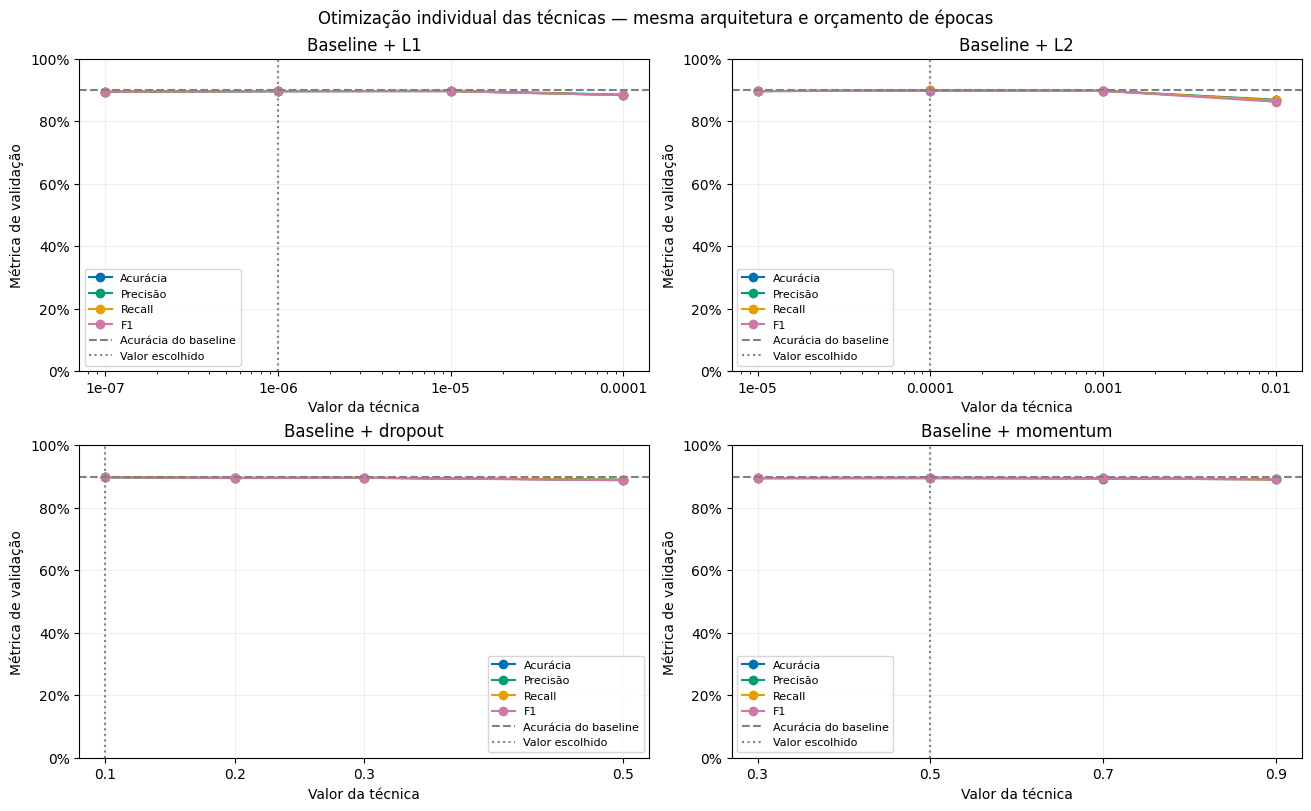

In [37]:
formato_tecnicas = {
    "Acurácia": "{:.2%}", "Precisão": "{:.2%}", "Recall": "{:.2%}", "F1": "{:.2%}",
    "Valor": "{:.6g}", "Perda validação": "{:.4f}", "Tempo (s)": "{:.1f}",
    "Diferença para baseline (p.p.)": "{:+.2f}",
}
display(resultado_otimizacao_tecnicas["tabela"].style.format(formato_tecnicas))
print("Melhor valor encontrado por técnica:")
display(resultado_otimizacao_tecnicas["melhores"][[
    "Técnica", "Valor", "Acurácia", "Precisão", "Recall", "F1", "Diferença para baseline (p.p.)"
]].style.format(formato_tecnicas))
plotar_otimizacao_tecnicas(resultado_otimizacao_tecnicas)

## 5. Combinações com os valores selecionados

Testamos as **16 combinações** de L1, L2, dropout e momentum, agora usando os valores escolhidos individualmente no tópico 4. Incluímos o baseline, quatro casos individuais, seis pares, quatro trios e as quatro técnicas juntas.

Os gráficos mostram acurácia, precisão, recall e F1 e as curvas de acurácia de treino e validação. A seleção dos valores e seus arquivos de origem são registrados junto aos resultados.

In [38]:
from itertools import combinations

def gerar_combinacoes(l1=1e-6, l2=1e-4, dropout=0.1, momentum=0.5):
    tecnicas = {
        "L1": ("l1", l1), "L2": ("l2", l2),
        "dropout": ("dropout", dropout), "momentum": ("momentum", momentum),
    }
    casos = {}
    for quantidade in range(5):
        for grupo in combinations(tecnicas, quantidade):
            nome = "Baseline" + (" + " + " + ".join(grupo) if grupo else "")
            casos[nome] = dict(tecnicas[tecnica] for tecnica in grupo)
    return casos

In [39]:
config_combinacoes = copy.deepcopy(resultado_otimizacao_tecnicas["config_base"])
casos_combinacoes = gerar_combinacoes(**resultado_otimizacao_tecnicas["melhores_valores"])

pasta_combinacoes = BASE_DIR / "results/classification" / (
    "combinacoes_" + datetime.now().strftime("%Y%m%d_%H%M%S_%f")
)
pasta_combinacoes.mkdir(parents=True, exist_ok=True)
(pasta_combinacoes / "origem_otimizacao.json").write_text(
    json.dumps({
        "arquivo_selecao": str(resultado_otimizacao_tecnicas["output_dir"] / "selecao.json"),
        "melhores_valores": resultado_otimizacao_tecnicas["melhores_valores"],
        "config_base": config_combinacoes,
        "seed": resultado_otimizacao_tecnicas["seed"],
    }, indent=2, ensure_ascii=False), encoding="utf-8"
)
resultado_combinacoes = executar_ablacoes(
    config_combinacoes,
    treino_ds=train_loader.dataset,
    validacao_ds=val_loader.dataset,
    nomes_classes=class_names,
    seed=resultado_otimizacao_tecnicas["seed"],
    output_dir=pasta_combinacoes,
    casos=casos_combinacoes,
)

Iniciando Baseline (1/16)...
Baseline | melhor época: 20 | validação: 89.83%
Iniciando Baseline + L1 (2/16)...
Baseline + L1 | melhor época: 17 | validação: 89.56%
Iniciando Baseline + L2 (3/16)...
Baseline + L2 | melhor época: 20 | validação: 89.74%
Iniciando Baseline + dropout (4/16)...
Baseline + dropout | melhor época: 20 | validação: 89.72%
Iniciando Baseline + momentum (5/16)...
Baseline + momentum | melhor época: 14 | validação: 89.42%
Iniciando Baseline + L1 + L2 (6/16)...
Baseline + L1 + L2 | melhor época: 20 | validação: 89.56%
Iniciando Baseline + L1 + dropout (7/16)...
Baseline + L1 + dropout | melhor época: 20 | validação: 89.96%
Iniciando Baseline + L1 + momentum (8/16)...
Baseline + L1 + momentum | melhor época: 14 | validação: 89.22%
Iniciando Baseline + L2 + dropout (9/16)...
Baseline + L2 + dropout | melhor época: 20 | validação: 89.79%
Iniciando Baseline + L2 + momentum (10/16)...
Baseline + L2 + momentum | melhor época: 14 | validação: 89.34%
Iniciando Baseline + dr

,Modelo,Acurácia,Precisão,Recall,F1,Melhor época,Tempo (s)
6,Baseline + L1 + dropout,89.96%,89.94%,89.97%,89.93%,20,52.9
0,Baseline,89.83%,89.88%,89.86%,89.84%,20,38.5
11,Baseline + L1 + L2 + dropout,89.83%,89.82%,89.84%,89.80%,20,64.4
8,Baseline + L2 + dropout,89.79%,89.78%,89.80%,89.77%,20,53.5
13,Baseline + L1 + dropout + momentum,89.75%,89.86%,89.77%,89.63%,20,52.6
2,Baseline + L2,89.74%,89.77%,89.77%,89.76%,20,52.1
3,Baseline + dropout,89.72%,89.70%,89.74%,89.71%,20,41.3
10,Baseline + dropout + momentum,89.68%,89.67%,89.70%,89.63%,20,41.7
15,Baseline + L1 + L2 + dropout + momentum,89.67%,89.65%,89.69%,89.62%,20,68.3
14,Baseline + L2 + dropout + momentum,89.66%,89.73%,89.68%,89.55%,19,54.5


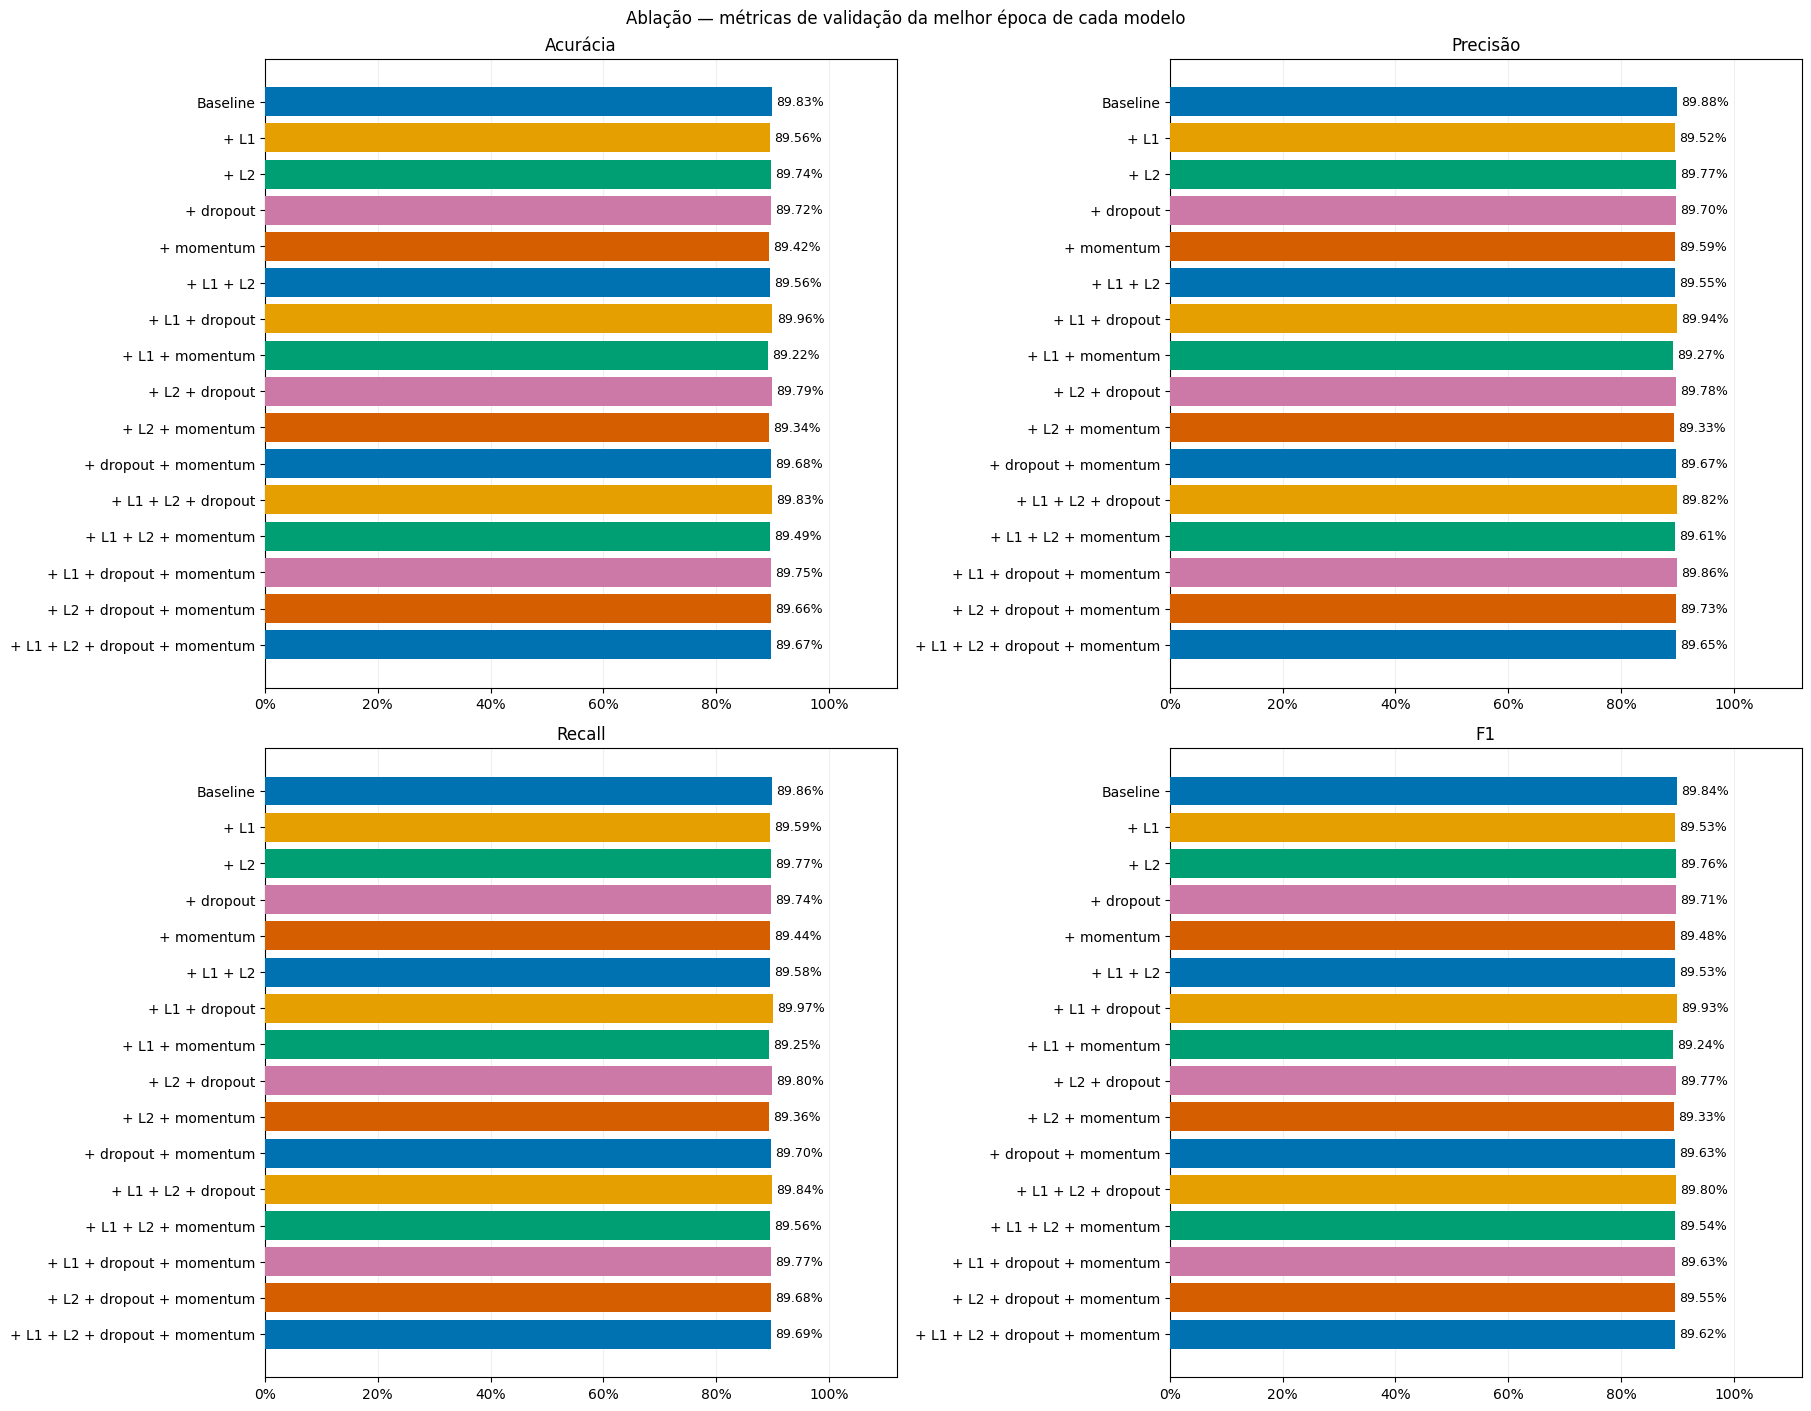

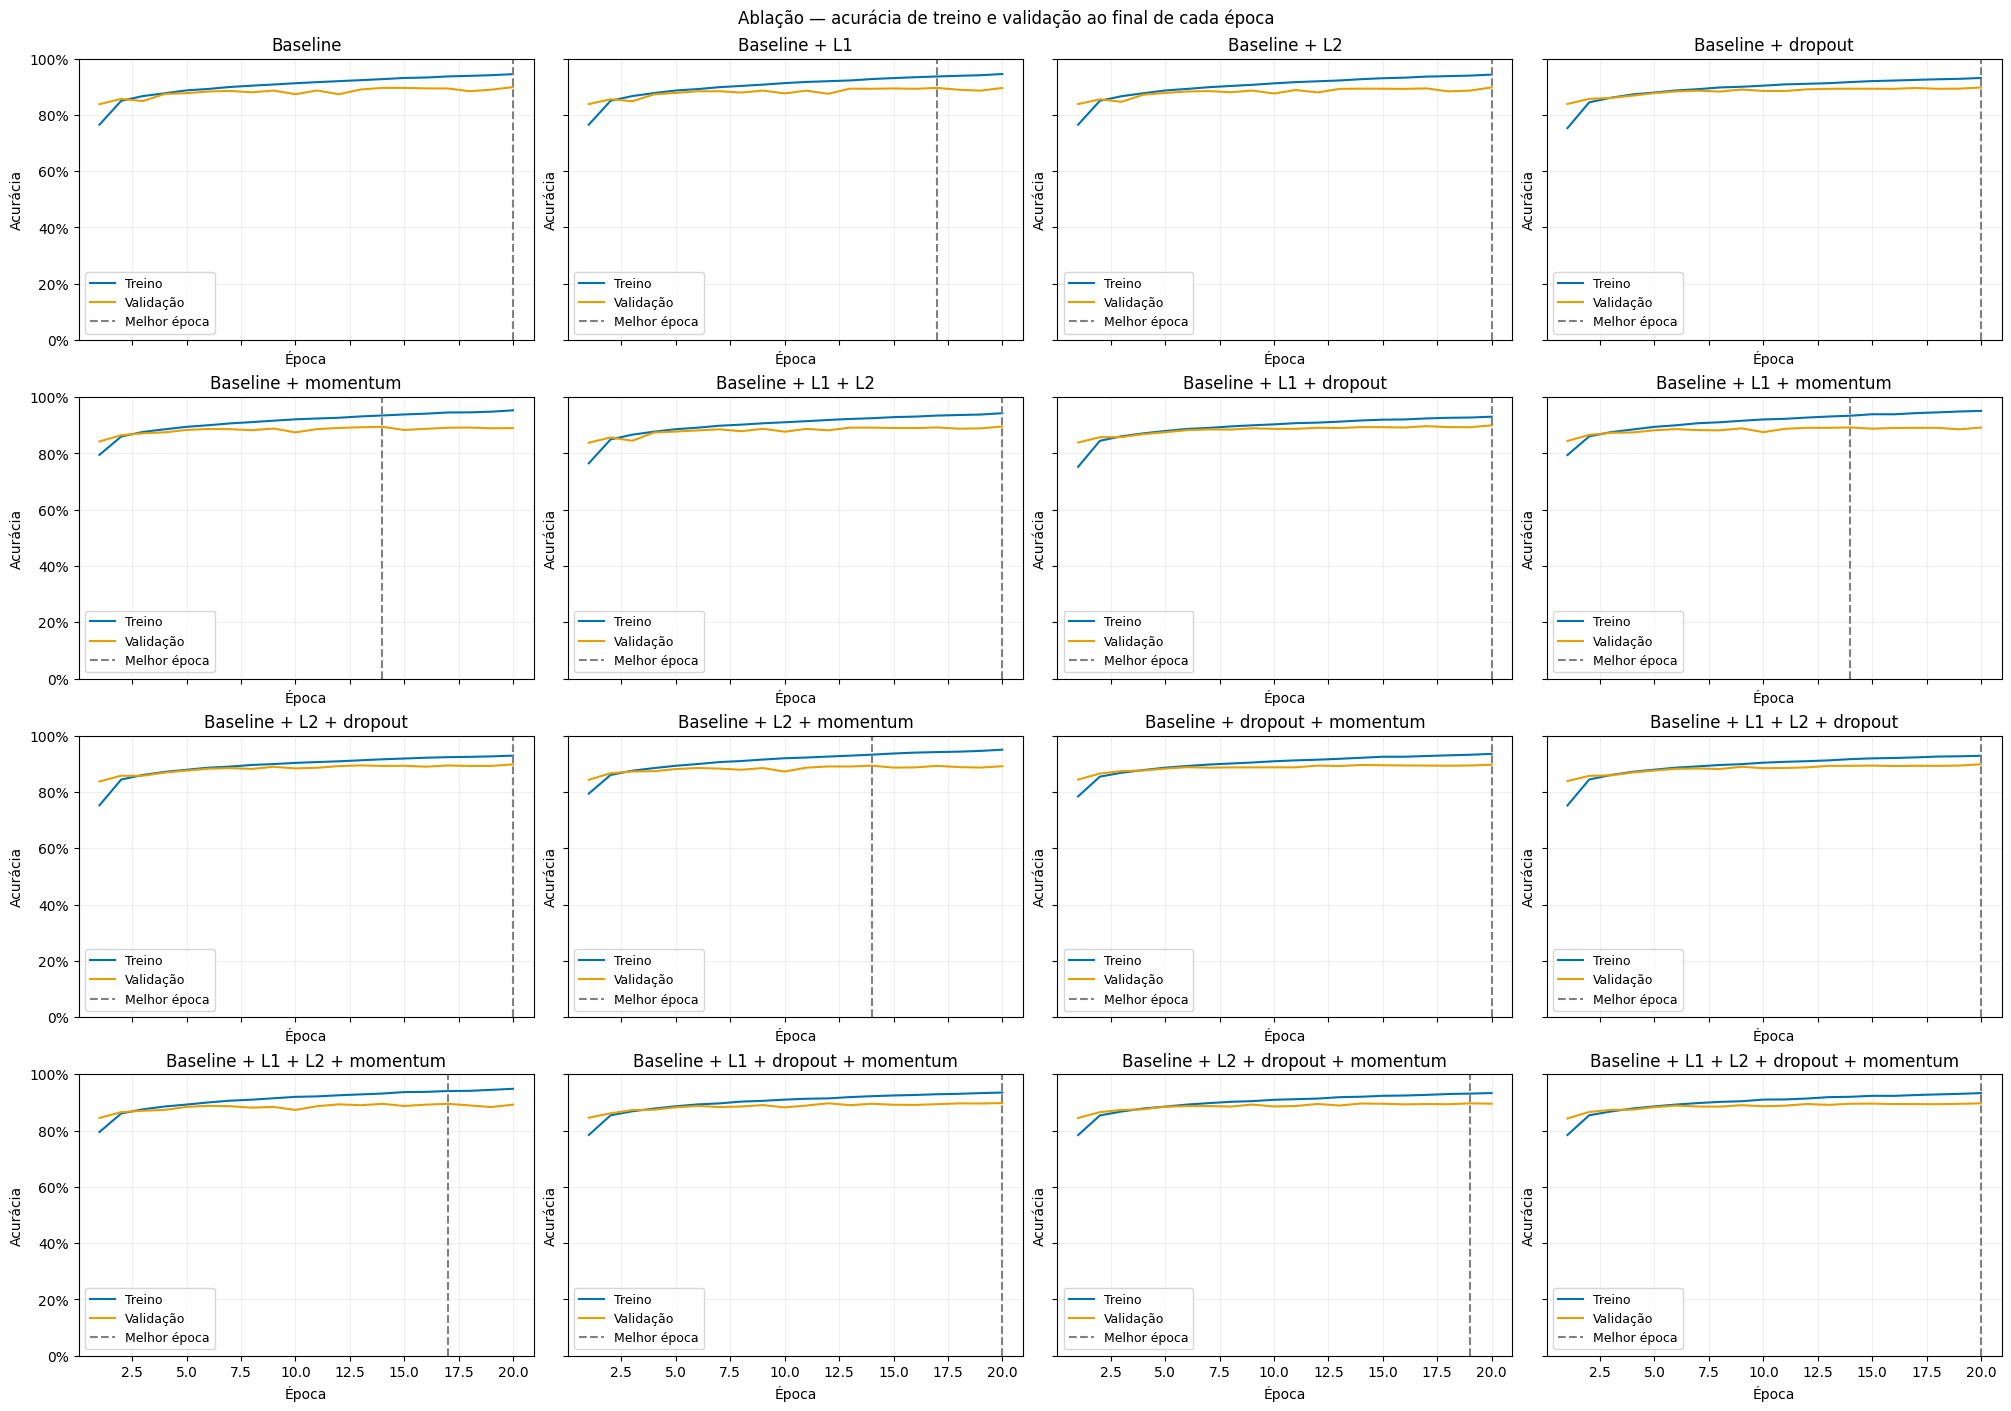

Maior acurácia de validação: Baseline + L1 + dropout — 89.96%


In [40]:
display(resultado_combinacoes["tabela"].sort_values("Acurácia", ascending=False).style.format({
    "Acurácia": "{:.2%}", "Precisão": "{:.2%}", "Recall": "{:.2%}",
    "F1": "{:.2%}", "Tempo (s)": "{:.1f}",
}))
plotar_ablacoes(resultado_combinacoes)
melhor_combinacao = resultado_combinacoes["tabela"].sort_values("Acurácia", ascending=False).iloc[0]
print(f"Maior acurácia de validação: {melhor_combinacao['Modelo']} — {melhor_combinacao['Acurácia']:.2%}")

## 6. Avaliação final no conjunto de teste

Selecionamos a combinação com maior acurácia de **validação**, usando a menor perda de validação como desempate. Depois aplicamos os pesos salvos ao teste, sem treinar novamente, e comparamos:

- **Configuração base:** configuração inicial, treinada com o mesmo número de épocas da busca.
- **Baseline final:** melhor MLP com SGD puro encontrada pelo Optuna.
- **Modelo final:** melhor combinação de técnicas do tópico 5.

A tabela apresenta acurácia, precisão, recall e F1 no mesmo conjunto de teste. 

In [41]:
# Seleciona apenas pela validação; acompanha automaticamente novas execuções.
nome_modelo_final, resultado_modelo_final = max(
    resultado_combinacoes["resultados"].items(),
    key=lambda item: (
        item[1]["resumo"]["validacao"]["accuracy"],
        -item[1]["resumo"]["validacao"]["loss"],
    ),
)
modelo_final = {
    "nome": nome_modelo_final,
    "config": copy.deepcopy(resultado_modelo_final["resumo"]["config"]),
    "checkpoint": Path(resultado_modelo_final["output_dir"]) / "melhor_modelo.pt",
}
print(f"Modelo final: {modelo_final['nome']}")
print(f"Acurácia de validação: {resultado_modelo_final['resumo']['validacao']['accuracy']:.2%}")
print(f"Configuração: {modelo_final['config']}")


Modelo final: Baseline + L1 + dropout
Acurácia de validação: 89.96%
Configuração: {'arquitetura': [256, 256, 256], 'ativacao': 'relu', 'learning_rate': 0.05821445965092194, 'batch_size': 64, 'epochs': 20, 'optimizer': 'sgd', 'l1': 1e-06, 'l2': 0.0, 'dropout': 0.1, 'momentum': 0.0}


In [42]:
checkpoints_finais = {
    "Configuração base": busca_optuna["modelo_inicial_path"],
    "Baseline final": optuna_best["checkpoint"],
    "Modelo final": modelo_final["checkpoint"],
}
device_teste_final = torch.device("cuda" if torch.cuda.is_available() else "cpu")
metricas_finais, detalhes_finais = {}, {}
for nome, caminho in checkpoints_finais.items():
    checkpoint = torch.load(caminho, map_location="cpu", weights_only=True)
    if list(checkpoint["class_names"]) != list(class_names):
        raise ValueError("A ordem das classes do checkpoint difere da ordem dos dados.")
    modelo_teste = criar_modelo_ablacao(checkpoint["config"], len(class_names))
    modelo_teste.load_state_dict(checkpoint["model_state_dict"])
    modelo_teste.to(device_teste_final)
    modelo_teste.eval()
    avaliacao = avaliar_modelo(
        modelo_teste, test_loader, nn.CrossEntropyLoss(), device_teste_final, class_names,
    )
    medias = avaliacao["relatorio"]["macro avg"]
    metricas_finais[nome] = {
        "Acurácia": avaliacao["accuracy"],
        "Precisão": medias["precision"],
        "Recall": medias["recall"],
        "F1": medias["f1-score"],
    }
    detalhes_finais[nome] = {
        "checkpoint": str(caminho), "config": checkpoint["config"],
        "melhor_epoca": checkpoint["epoch"], "seed": checkpoint["seed"],
        "amostras_teste": len(test_loader.dataset), "classes": list(class_names),
        "avaliacao_teste": avaliacao,
    }
    del modelo_teste

tabela_final = pd.DataFrame.from_dict(metricas_finais, orient="index")
tabela_final.index.name = "Modelo"
print(f"Resultados no teste — modelo final: {modelo_final['nome']}")
display(tabela_final.style.format("{:.2%}"))

pasta_teste_final = Path(resultado_combinacoes["output_dir"]) / "teste_final"
pasta_teste_final.mkdir(parents=True, exist_ok=True)
tabela_final.to_csv(pasta_teste_final / "comparacao_teste.csv")
(pasta_teste_final / "detalhes.json").write_text(
    json.dumps({"combinacao_selecionada": modelo_final["nome"], "modelos": detalhes_finais},
               indent=2, ensure_ascii=False), encoding="utf-8",
)
print(f"Resultados salvos em: {pasta_teste_final}")


Resultados no teste — modelo final: Baseline + L1 + dropout


,Acurácia,Precisão,Recall,F1
Modelo,,,,
Configuração base,87.00%,87.25%,87.00%,87.06%
Baseline final,88.54%,88.71%,88.54%,88.60%
Modelo final,89.14%,89.14%,89.14%,89.12%


Resultados salvos em: C:\Users\davis\Documents\vscode\redesNeuraisUC\mlp_rn\results\classification\combinacoes_20260915_145526_037519\teste_final
